# Stellar Classification: Machine Learning Tutorial

## Overview

This tutorial demonstrates machine learning classification techniques using real astronomical data from the **Sloan Digital Sky Survey (SDSS)**. The goal is to classify stars as either:
- **Class 0**: Normal Stars
- **Class 1**: RR Lyrae Variable Stars

### What are RR Lyrae Stars?

**RR Lyrae stars** are an important class of variable stars that exhibit regular, short-period brightness oscillations (typically 0.2-1 day periods). They are:
- **Evolutionary markers**: Found primarily in old stellar populations
- **Distance indicators**: Used to measure distances to nearby galaxies and globular clusters
- **Scientific importance**: Help us understand stellar evolution and galaxy structure

### Dataset Description

We use the **RR Lyrae Combined Dataset** from the AstroML library, which contains photometric observations from the SDSS. The dataset includes:

**Features** (4 photometric color indices):
- **u-g**
- **g-r**
- **r-i**
- **i-z**

These color differences encode information about stellar temperature, composition, and physical properties, allowing us to distinguish RR Lyrae stars from normal stars.

**Class Distribution**: Highly imbalanced (~96% normal stars, ~4% RR Lyrae) - realistic for astronomical surveys

### Tutorial Structure

This tutorial progresses through several classification algorithms:

1. **kNN (k-Nearest Neighbors)** - Simple baseline, explores effect of k parameter
2. **Decision Trees** - Interpretable rules, explores tree depth effects
3. **Random Forests** - Ensemble method with feature importance analysis
4. **Grid Search Optimization** - Systematic hyperparameter tuning using cross-validation

### Key Concepts Covered

- **Hyperparameter tuning**: How to optimize model parameters for better performance
- **Cross-validation**: k-fold CV for robust evaluation on limited data
- **Imbalanced classification**: Handling datasets with unequal class distributions
- **Model evaluation metrics**: Accuracy, balanced accuracy, precision, recall, F1-score
- **Overfitting detection**: Comparing training vs. testing performance
- **Feature importance**: Understanding which features matter most for classification

### References

AstroML Library Documentation: https://www.astroml.org/modules/generated/astroML.datasets.fetch_rrlyrae_combined.html

---

## Code Documentation & Workflow

The notebook follows this workflow:

1. **Import Libraries** - Load required packages for data processing and machine learning
2. **Load Dataset** - Fetch the RR Lyrae combined dataset from AstroML
3. **Data Exploration** - Convert to pandas DataFrame, visualize distributions
4. **Data Preparation** - Create train/test splits with stratification to maintain class ratios
5. **Algorithm Testing** - Train multiple classifiers with hyperparameter variations
        
    5.1 **Evaluation** - Generate confusion matrices, classification reports, and visualizations

    5.2 **Optimization** - Use grid search for systematic hyperparameter tuning

6. **Comparison** - Compare algorithm performance across multiple metrics

--- 
# Import

In [1]:
from astroML.datasets import fetch_rrlyrae_combined
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, 
                             confusion_matrix, classification_report, 
                             recall_score, precision_score, f1_score)
import numpy as np
from sklearn.model_selection import GridSearchCV

# Read in the dataset

In [2]:
# Read combined RR Lyrae stars from the SDSS S82 catalog
rrlyrae_combined_data = fetch_rrlyrae_combined()

In [3]:
# Extract features from the combined RR Lyrae dataset
X = rrlyrae_combined_data[0]
# Extract labels from the combined RR Lyrae dataset
y = rrlyrae_combined_data[1]

In [4]:
X.shape, y.shape

((93141, 4), (93141,))

# Explore the dataset

For this task, we will transform the dataset to a pandas DataFrame. 

In [5]:
# Create a dataframe with features X and labels y
df = pd.DataFrame(X, columns=['u-g', 'g-r', 'r-i', 'i-z'])
df['Star_type'] = y

In [6]:
df

,u-g,g-r,r-i,i-z,Star_type
0,1.250999,0.394000,0.137000,0.061999,0.0
1,1.048000,0.339001,0.151999,0.023001,0.0
2,1.008001,0.341999,0.129000,0.203001,0.0
3,0.965000,0.392000,0.149000,0.150000,0.0
4,1.040001,0.333000,0.125999,0.101999,0.0
...,...,...,...,...,...
93136,0.962999,0.059000,-0.025999,-0.025000,1.0
93137,1.059999,0.185001,0.050999,-0.023998,1.0
93138,1.044001,0.212000,0.035000,0.002001,1.0
93139,1.064999,0.172001,0.042000,0.003000,1.0


In [7]:
# Drop part of the normal stars since they are overrepresented in the dataset
normal_stars = df[df['Star_type'] == 0]
normal_stars = normal_stars.sample(frac=0.4, random_state=42)  # Keep only 40% of normal stars
df = pd.concat([df[df['Star_type'] != 0], normal_stars])  # Combine with the rest of the dataset

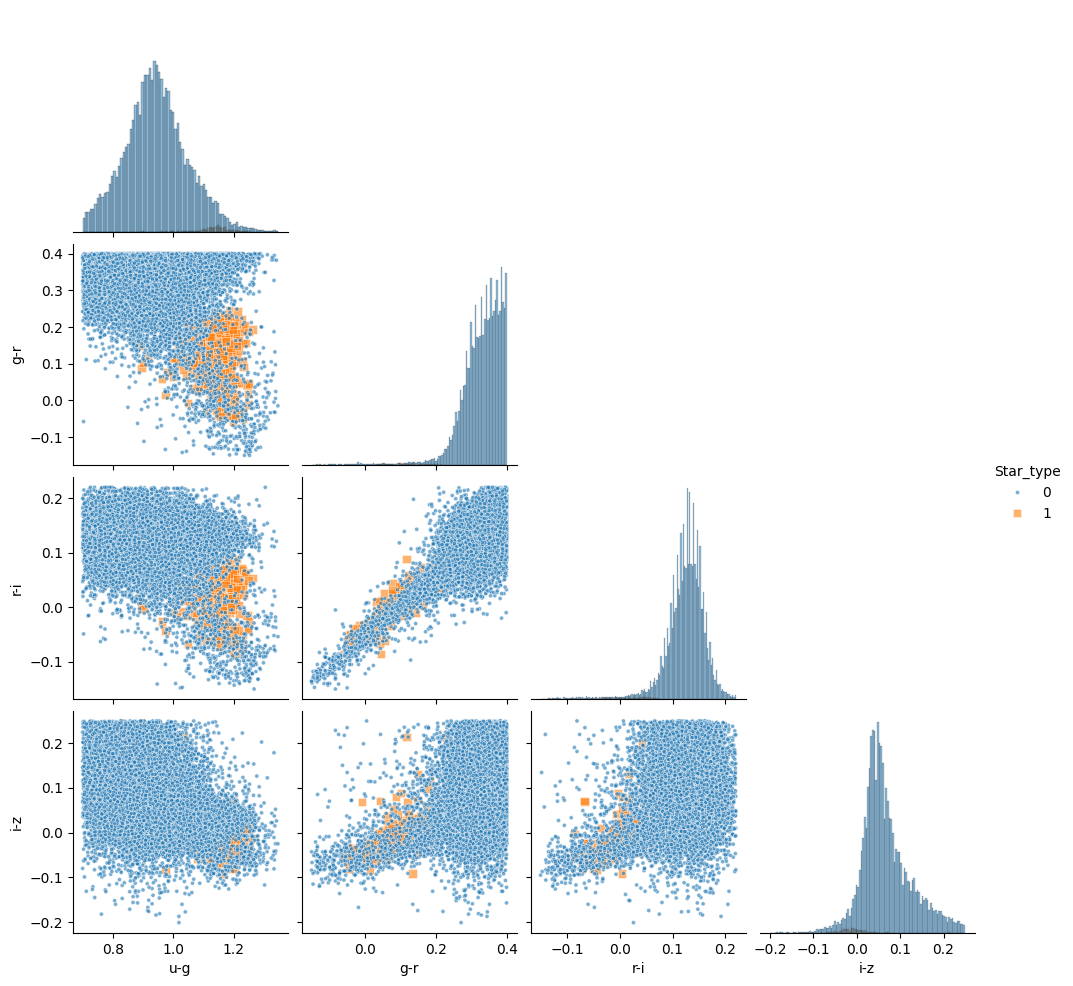

In [8]:
# Create a corner plot with scatter plots colored by star type
sns.pairplot(df, 
             hue='Star_type', 
             hue_order=[0, 1],
             diag_kind='hist', 
             plot_kws={'alpha': 0.6}, 
             markers=['.', 's'],
             corner=True
             )

plt.show()

----

# kNN

## Introduction to k-Nearest Neighbors (kNN)

The **k-Nearest Neighbors** algorithm is one of the simplest yet powerful classification algorithms in machine learning. Here's how it works:

1. **Core Idea**: To classify a new data point, kNN finds the k closest training examples and assigns the label that appears most frequently among those neighbors.

2. **Distance Metric**: By default, it uses Euclidean distance, which measures the straight-line distance between points in feature space.

3. **Why Test Different k Values?**
   - **Small k (e.g., k=1)**: The model is very flexible and sensitive to individual data points. It may overfit the training data.
   - **Large k (e.g., k=30)**: The model becomes more rigid and may underfit, missing important patterns.
   - **Optimal k**: Balances between fitting the training data well and generalizing to new unseen data.

In this tutorial, we'll explore how different k values affect the classification of stars:
- **Class 0**: Normal stars
- **Class 1**: RR Lyrae variable stars (which have distinctive brightness variations)

These star types have different color patterns in the four photometric bands (u, g, r, i, z), which we'll use as features.

### Step 1: Prepare the Data

We split our dataset into two parts:
- **Training Set (80%)**: Used to train the kNN model by building the index of training samples
- **Testing Set (20%)**: Used to evaluate how well the model generalizes to unseen data

The class distribution tells us if the dataset is balanced or if one class dominates.

In [10]:
# Split the data into training and testing sets
# IMPORTANT: Use stratified split to maintain class distribution
X = df[['u-g', 'g-r', 'r-i', 'i-z']]
y = df['Star_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in testing set:")
print(y_test.value_counts())

Training set size: 30036
Testing set size: 7510

Class distribution in training set:
Star_type
0.0    29650
1.0      386
Name: count, dtype: int64

Class distribution in testing set:
Star_type
0.0    7413
1.0      97
Name: count, dtype: int64


### Step 2: Hyperparameter Tuning - Testing Different k Values

Here we systematically test k values from 1 to 40 and measure the accuracy on both training and testing sets.

- **Training Accuracy**: How well the model fits the training data
- **Testing Accuracy**: How well the model generalizes to new, unseen data (more important!)

A large gap between training and testing accuracy indicates **overfitting** - the model memorized the training data but doesn't generalize well.

In [11]:
# Test different values of k
k_values = range(1, 41)
train_accuracies = []
test_accuracies = []

for k in k_values:
    # Create and train the kNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Calculate accuracies
    train_acc = balanced_accuracy_score(y_train, knn.predict(X_train))
    test_acc = balanced_accuracy_score(y_test, knn.predict(X_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

print("k values and their corresponding test accuracies:")
for k, acc in zip(k_values, test_accuracies):
    print(f"k={k:2d} -> Test Accuracy: {acc:.4f}")

k values and their corresponding test accuracies:
k= 1 -> Test Accuracy: 0.8837
k= 2 -> Test Accuracy: 0.8285
k= 3 -> Test Accuracy: 0.8897
k= 4 -> Test Accuracy: 0.8645
k= 5 -> Test Accuracy: 0.8948
k= 6 -> Test Accuracy: 0.8695
k= 7 -> Test Accuracy: 0.8949
k= 8 -> Test Accuracy: 0.8901
k= 9 -> Test Accuracy: 0.9053
k=10 -> Test Accuracy: 0.8848
k=11 -> Test Accuracy: 0.8952
k=12 -> Test Accuracy: 0.8848
k=13 -> Test Accuracy: 0.8898
k=14 -> Test Accuracy: 0.8899
k=15 -> Test Accuracy: 0.8950
k=16 -> Test Accuracy: 0.8796
k=17 -> Test Accuracy: 0.9002
k=18 -> Test Accuracy: 0.8847
k=19 -> Test Accuracy: 0.9053
k=20 -> Test Accuracy: 0.8899
k=21 -> Test Accuracy: 0.9002
k=22 -> Test Accuracy: 0.8900
k=23 -> Test Accuracy: 0.9053
k=24 -> Test Accuracy: 0.8951
k=25 -> Test Accuracy: 0.9054
k=26 -> Test Accuracy: 0.8951
k=27 -> Test Accuracy: 0.9002
k=28 -> Test Accuracy: 0.8951
k=29 -> Test Accuracy: 0.8950
k=30 -> Test Accuracy: 0.8951
k=31 -> Test Accuracy: 0.8950
k=32 -> Test Accurac

### Step 3: Visualize the Effect of k on Model Performance

This plot shows:
- **Blue line with circles**: Training accuracy across different k values (usually decreases as k increases)
- **Orange line with squares**: Testing accuracy (what we care about most)

Look for:
- The k value where testing accuracy is highest (the "elbow" or peak)
- The gap between training and testing accuracy (smaller gap = better generalization)
- The point where testing accuracy stabilizes or starts to decrease

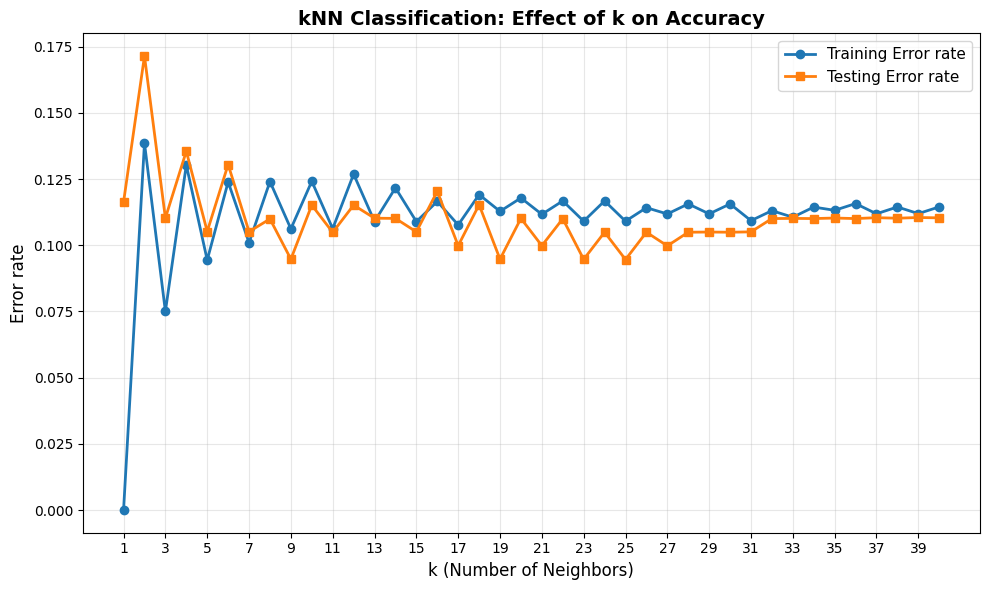


Best k value: 25
Best test accuracy: 0.9054


In [12]:
# Visualize how k affects classification accuracy
# Visualize how k affects classification accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, np.ones_like(train_accuracies) - train_accuracies, marker='o', label='Training Error rate', linewidth=2)
plt.plot(k_values, np.ones_like(test_accuracies) - test_accuracies, marker='s', label='Testing Error rate', linewidth=2)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Error rate', fontsize=12)
plt.title('kNN Classification: Effect of k on Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 41, 2))
# plt.ylim([0.98, 1.001])
plt.tight_layout()
plt.show()

# Find the best k value
best_k = k_values[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)
print(f"\nBest k value: {best_k}")
print(f"Best test accuracy: {best_accuracy:.4f}")

### Step 4: Detailed Evaluation of the Best Model

Now we evaluate the optimal kNN model using multiple metrics:

**Confusion Matrix** shows:
- **True Positives (TP)**: Correctly identified as RR Lyrae
- **True Negatives (TN)**: Correctly identified as Normal Star  
- **False Positives (FP)**: Incorrectly classified as RR Lyrae (Type I error)
- **False Negatives (FN)**: Incorrectly classified as Normal Star (Type II error)

**Key Metrics**:
- **Precision**: Of all predicted RR Lyrae stars, how many were actually RR Lyrae? (TP / (TP + FP))
- **Recall (Sensitivity)**: Of all actual RR Lyrae stars, how many did we correctly identify? (TP / (TP + FN))
- **F1-Score**: Harmonic mean of precision and recall - a balanced metric
- **Support**: Number of samples in each class

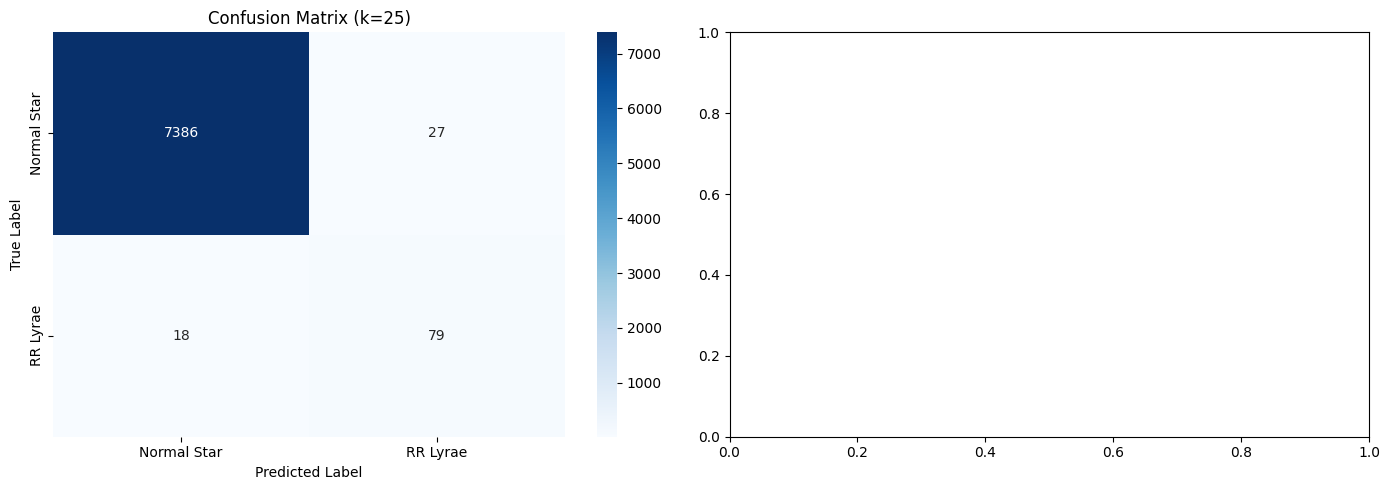


Detailed Results for kNN with k=25
              precision    recall  f1-score   support

 Normal Star       1.00      1.00      1.00      7413
    RR Lyrae       0.75      0.81      0.78        97

    accuracy                           0.99      7510
   macro avg       0.87      0.91      0.89      7510
weighted avg       0.99      0.99      0.99      7510



In [14]:
# Train the best kNN model and evaluate in detail
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

# Make predictions
y_pred = best_knn.predict(X_test)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal Star', 'RR Lyrae'],
            yticklabels=['Normal Star', 'RR Lyrae'])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title(f'Confusion Matrix (k={best_k})')

# Classification Report
report = classification_report(y_test, y_pred, target_names=['Normal Star', 'RR Lyrae'], output_dict=True)
report_df = pd.DataFrame(report).transpose()
# sns.heatmap(report_df.iloc[:-1, :-1], annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], cbar=False)
# axes[1].set_title(f'Classification Report (k={best_k})')

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Detailed Results for kNN with k={best_k}")
print(f"{'='*50}")
print(classification_report(y_test, y_pred, target_names=['Normal Star', 'RR Lyrae']))

-----

# Decision Trees Classification

## Introduction to Decision Trees

A **Decision Tree** is a tree-like model that makes predictions by recursively splitting the feature space based on feature values.

**How it works**:
1. The algorithm starts with all data at the root node
2. It selects the feature and threshold that best separates the classes (usually based on Gini impurity or information gain)
3. It recursively splits each node until reaching a stopping criterion
4. Leaf nodes represent class predictions

**Key Concept - Tree Depth**:
- **Shallow trees (small max_depth)**: Simple rules, fast training, may underfit
- **Deep trees (large max_depth)**: Complex rules, can capture intricate patterns, may overfit
- **Optimal depth**: Balances between bias and variance, generalizes well to new data

**Advantages over kNN**:
- Provides **interpretable rules** (you can see exactly how decisions are made)
- Works with both numerical and categorical features
- Doesn't require scaling of features
- Much faster predictions for large datasets

We'll use the same stellar dataset to classify stars as Normal or RR Lyrae using Decision Trees.

### Step 1: Train Decision Trees with Different Depths

We systematically train Decision Trees with maximum depths ranging from 1 to 20. The `max_depth` parameter controls the complexity:
- **max_depth=1**: A single split (stumpy tree, very simple)
- **max_depth=10-15**: Usually where optimal models live
- **max_depth=20+**: Very deep trees that may memorize training data

Like with kNN, we track both training and testing accuracy to detect overfitting.

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Test different tree depths
max_depths = range(1, 21)
dt_train_accuracies = []
dt_test_accuracies = []

for depth in max_depths:
    # Create and train the Decision Tree classifier
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion='entropy')
    dt.fit(X_train, y_train)
    
    # Calculate accuracies
    train_acc = balanced_accuracy_score(y_train, dt.predict(X_train))
    test_acc = balanced_accuracy_score(y_test, dt.predict(X_test))
    
    dt_train_accuracies.append(train_acc)
    dt_test_accuracies.append(test_acc)

print("max_depth values and their corresponding test accuracies:")
for depth, acc in zip(max_depths, dt_test_accuracies):
    print(f"max_depth={depth:2d} -> Test Accuracy: {acc:.4f}")

# Find the best max_depth value
best_depth = max_depths[np.argmax(dt_test_accuracies)]
best_dt_accuracy = max(dt_test_accuracies)
print(f"\nBest max_depth value: {best_depth}")
print(f"Best test accuracy: {best_dt_accuracy:.4f}")

max_depth values and their corresponding test accuracies:
max_depth= 1 -> Test Accuracy: 0.5000
max_depth= 2 -> Test Accuracy: 0.5000
max_depth= 3 -> Test Accuracy: 0.8891
max_depth= 4 -> Test Accuracy: 0.8842
max_depth= 5 -> Test Accuracy: 0.8332
max_depth= 6 -> Test Accuracy: 0.8488
max_depth= 7 -> Test Accuracy: 0.8590
max_depth= 8 -> Test Accuracy: 0.8840
max_depth= 9 -> Test Accuracy: 0.8895
max_depth=10 -> Test Accuracy: 0.8897
max_depth=11 -> Test Accuracy: 0.8844
max_depth=12 -> Test Accuracy: 0.8790
max_depth=13 -> Test Accuracy: 0.8686
max_depth=14 -> Test Accuracy: 0.8791
max_depth=15 -> Test Accuracy: 0.8790
max_depth=16 -> Test Accuracy: 0.8687
max_depth=17 -> Test Accuracy: 0.8789
max_depth=18 -> Test Accuracy: 0.8739
max_depth=19 -> Test Accuracy: 0.8842
max_depth=20 -> Test Accuracy: 0.8842

Best max_depth value: 10
Best test accuracy: 0.8897


### Step 2: Visualize the Effect of Tree Depth on Model Performance

This plot compares Decision Tree performance across different depths:
- **Blue line with circles**: Training accuracy (usually stays high or reaches 100% with deep trees)
- **Orange line with squares**: Testing accuracy (the metric we care about most)
- **Red dashed line**: Marks the optimal tree depth

Notice the classic overfitting pattern:
- Training accuracy often reaches 100% for deep trees
- Testing accuracy peaks at an optimal depth, then may decline as the tree becomes too complex
- The gap between training and testing accuracy indicates overfitting severity

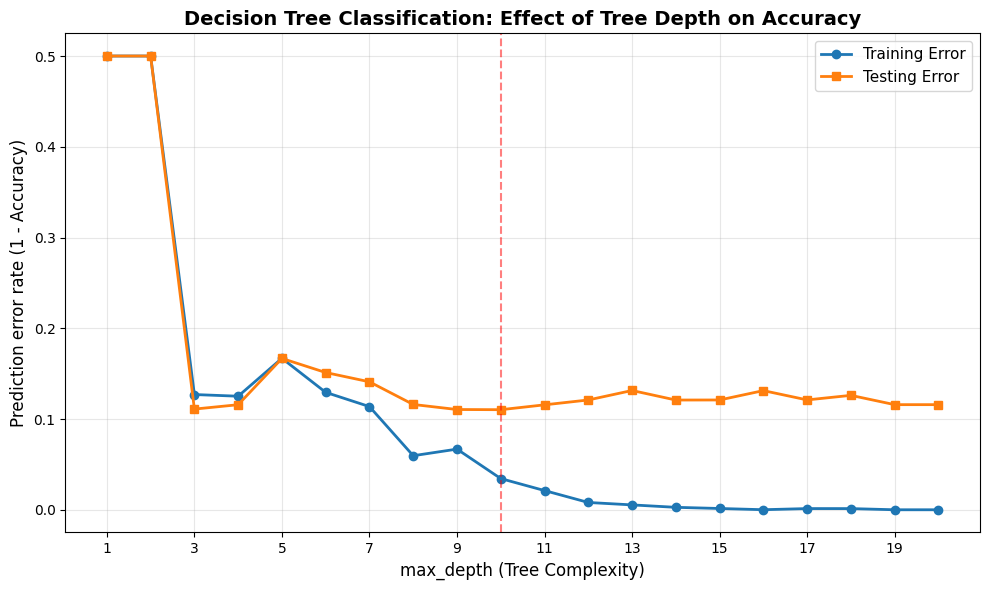


Best max_depth value: 10
Best test accuracy: 0.8897


In [17]:
# Visualize how max_depth affects classification accuracy
plt.figure(figsize=(10, 6))
plt.plot(max_depths, np.ones(len(dt_train_accuracies))-dt_train_accuracies, marker='o', label='Training Error', linewidth=2)
plt.plot(max_depths, np.ones(len(dt_test_accuracies))-dt_test_accuracies, marker='s', label='Testing Error', linewidth=2)
plt.xlabel('max_depth (Tree Complexity)', fontsize=12)
plt.ylabel('Prediction error rate (1 - Accuracy)', fontsize=12)
plt.title('Decision Tree Classification: Effect of Tree Depth on Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21, 2))
# plt.ylim([0.99, 1.01])
plt.axvline(x=best_depth, color='red', linestyle='--', alpha=0.5, label=f'Best depth={best_depth}')
plt.tight_layout()
plt.show()

print(f"\nBest max_depth value: {best_depth}")
print(f"Best test accuracy: {best_dt_accuracy:.4f}")

### Step 3: Detailed Evaluation of the Best Decision Tree Model

The same evaluation metrics as the kNN model apply here:

**Confusion Matrix** shows the classification outcomes:
- **True Positives (TP)**: Correctly identified as RR Lyrae
- **True Negatives (TN)**: Correctly identified as Normal Star  
- **False Positives (FP)**: Incorrectly classified as RR Lyrae
- **False Negatives (FN)**: Incorrectly classified as Normal Star

**Key Metrics**:
- **Precision**: Of all predicted RR Lyrae, how many were actually correct?
- **Recall**: Of all actual RR Lyrae stars, how many did we catch?
- **F1-Score**: Balanced average of precision and recall
- **Support**: Number of samples in each class in the test set

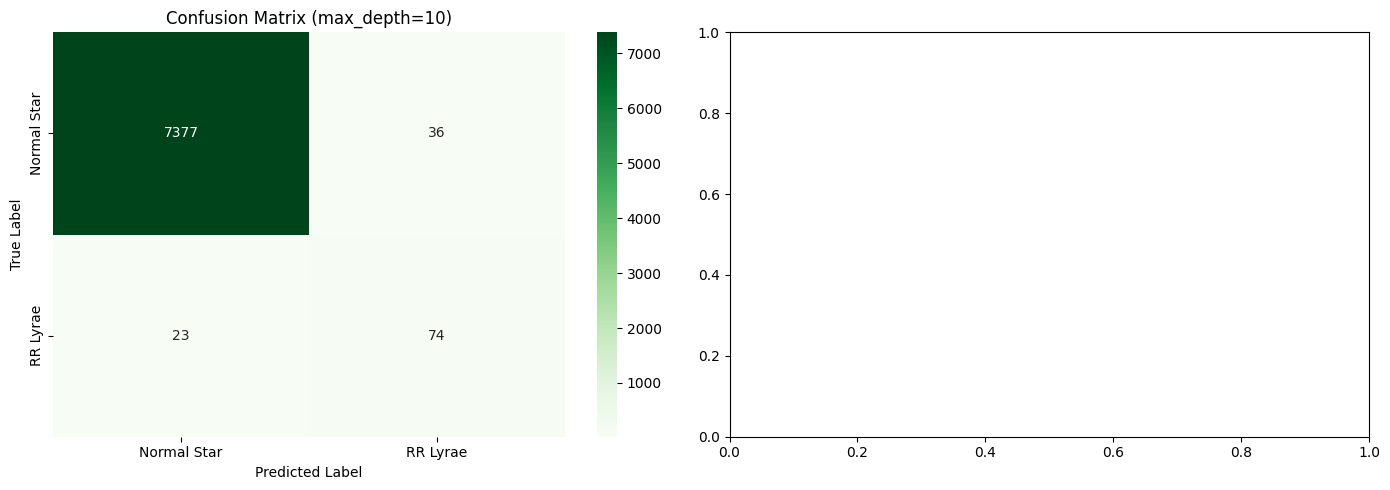


Detailed Results for Decision Tree (max_depth=10)
              precision    recall  f1-score   support

 Normal Star       1.00      1.00      1.00      7413
    RR Lyrae       0.67      0.76      0.71        97

    accuracy                           0.99      7510
   macro avg       0.83      0.88      0.86      7510
weighted avg       0.99      0.99      0.99      7510



In [18]:
# Train the best Decision Tree model and evaluate in detail
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = best_dt.predict(X_test)

# Calculate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0], 
            xticklabels=['Normal Star', 'RR Lyrae'],
            yticklabels=['Normal Star', 'RR Lyrae'])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title(f'Confusion Matrix (max_depth={best_depth})')

# Classification Report
report_dt = classification_report(y_test, y_pred_dt, target_names=['Normal Star', 'RR Lyrae'], output_dict=True)
report_df_dt = pd.DataFrame(report_dt).transpose()
# sns.heatmap(report_df_dt.iloc[:-1, :-1], annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], cbar=False)
# axes[1].set_title(f'Classification Report (max_depth={best_depth})')

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Detailed Results for Decision Tree (max_depth={best_depth})")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_dt, target_names=['Normal Star', 'RR Lyrae']))

### Step 4: Visualizing Decision Tree Structures

One of the main advantages of Decision Trees is **interpretability** - we can actually see the decision rules!

The following visualization shows the actual tree structure for three different depths:
- **max_depth=3**: A shallow tree with simple rules
- **max_depth=best_depth**: The optimal tree we selected
- **max_depth=10**: A deeper tree with more complex decision rules

Each node shows:
- **The condition** (feature and threshold) used to split the data
- **Gini impurity** (measure of data purity at that node; 0 means pure, 0.5 means mixed)
- **Sample count** and **value** (how many samples of each class)
- **Color intensity** (darker = more samples of one class, lighter = mixed)

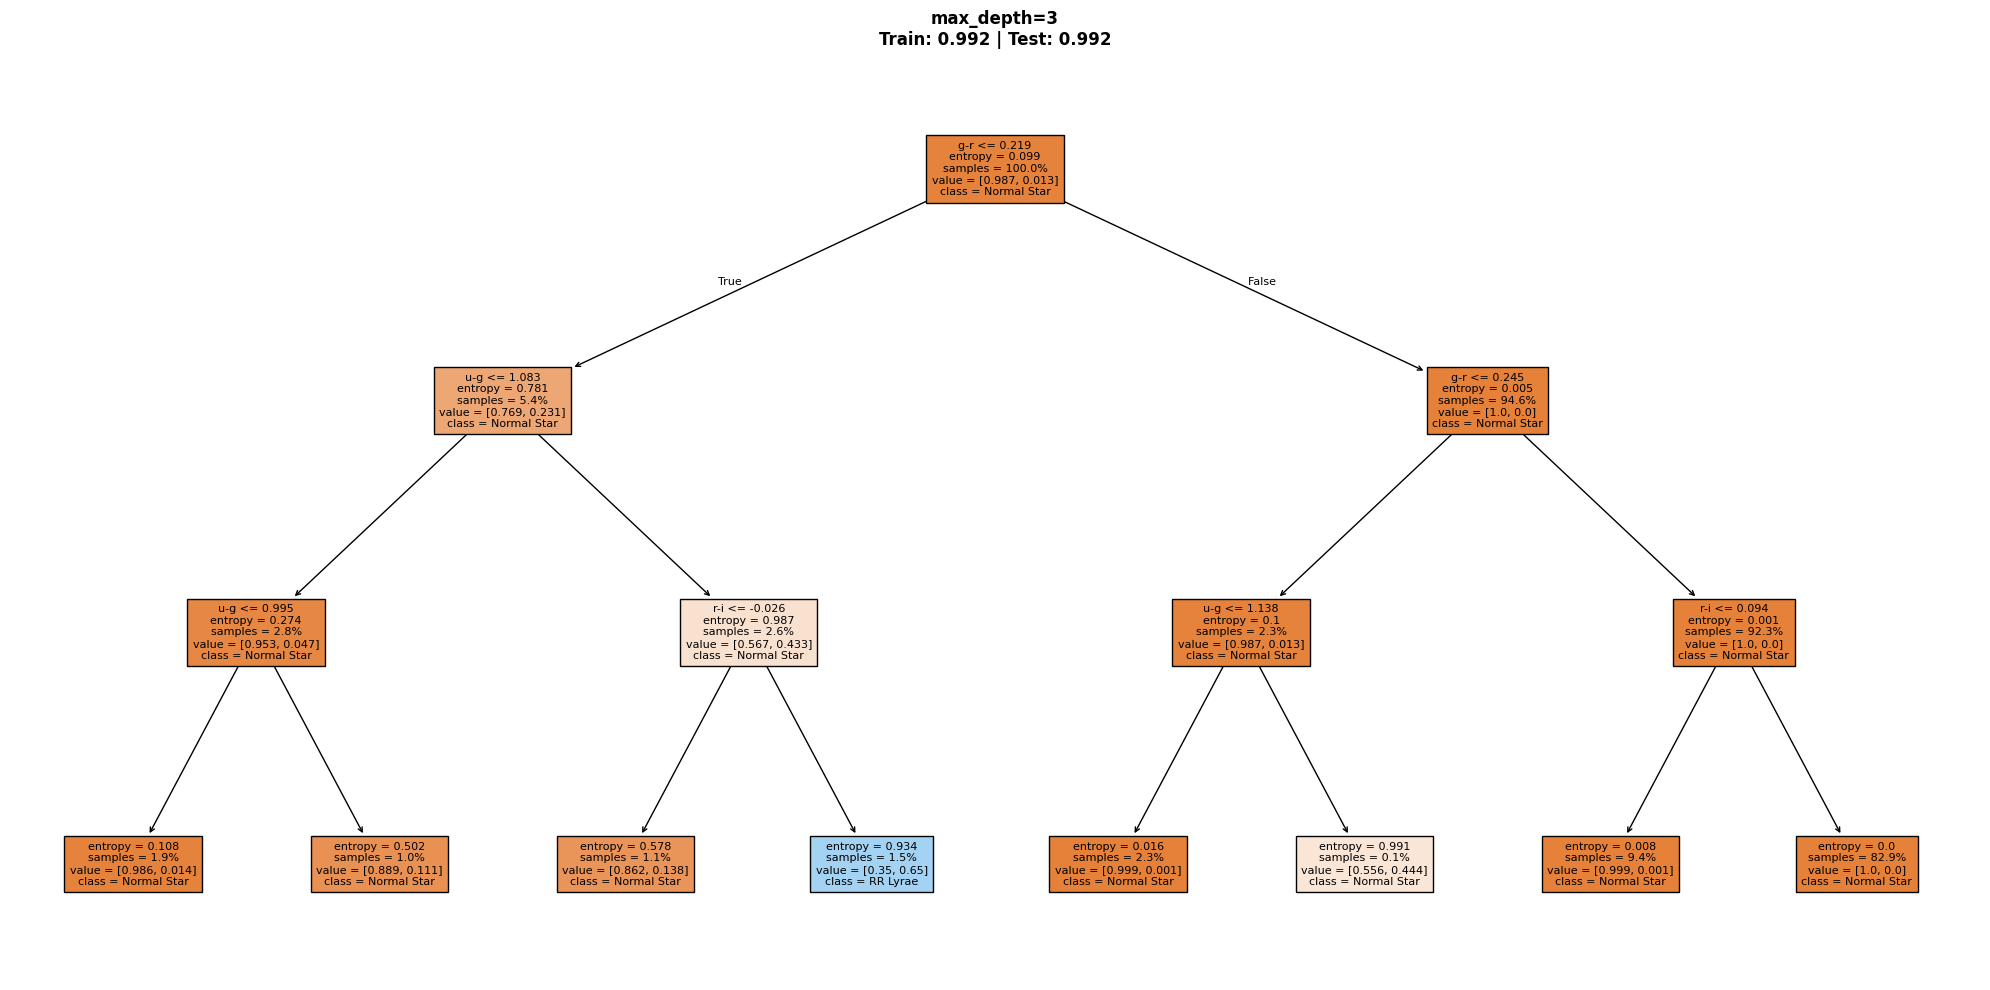

Tree Structure Visualization Complete

How to read the nodes:
- Condition at top: the feature and threshold for splitting
- gini: impurity measure (0=pure, 0.5=mixed)
- samples: number of training samples at this node
- value: [# normal stars, # RR Lyrae]
- Color: red=mostly RR Lyrae, blue=mostly Normal stars


In [22]:
# Visualize decision trees with different depths
depths_to_visualize = [3]
fig, axes = plt.subplots(1, 1, figsize=(20, 10))

for idx, depth in enumerate(depths_to_visualize):
    # Train tree with this depth
    dt_vis = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion='entropy')
    dt_vis.fit(X_train, y_train)
    
    # Calculate accuracy for this tree
    train_acc_dt = accuracy_score(y_train, dt_vis.predict(X_train))
    test_acc_dt = accuracy_score(y_test, dt_vis.predict(X_test))
    
    # Plot the tree
    plot_tree(dt_vis, 
              ax=axes,
              feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
              class_names=['Normal Star', 'RR Lyrae'],
              filled=True,
              fontsize=8,
              proportion=True)
    
    axes.set_title(f'max_depth={depth}\nTrain: {train_acc_dt:.3f} | Test: {test_acc_dt:.3f}', 
                        fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Tree Structure Visualization Complete")
print("\nHow to read the nodes:")
print("- Condition at top: the feature and threshold for splitting")
print("- gini: impurity measure (0=pure, 0.5=mixed)")
print("- samples: number of training samples at this node")
print("- value: [# normal stars, # RR Lyrae]")
print("- Color: red=mostly RR Lyrae, blue=mostly Normal stars")

### Step 5: k-Fold Cross Validation for Robust Hyperparameter Selection

In the previous approach, we split the data once into training and testing sets. However, the results can be **sensitive to how the data is split**. A more robust approach is **k-Fold Cross Validation**:

**How k-Fold Cross Validation Works**:
1. Divide the entire dataset into k equal-sized folds (e.g., 5 folds)
2. For each fold:
   - Use that fold as the **test set**
   - Use all other folds as the **training set**
   - Train the model and record the accuracy
3. Calculate the **mean accuracy** and **standard deviation** across all folds
4. The standard deviation tells us how stable the model is across different data splits

**Advantages**:
- **More reliable estimates**: Uses all data for both training and testing
- **Stability assessment**: Standard deviation shows if performance varies across folds
- **Better use of limited data**: No data is wasted (unlike a single train-test split)
- **Reduces variance**: Multiple splits give a more robust estimate of true performance

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

# Use 5-fold cross validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Test different tree depths using cross validation
max_depths_cv = range(1, 21)
cv_mean_accuracies = []
cv_std_accuracies = []

print(f"Performing {n_splits}-Fold Cross Validation for Decision Tree Depths...\n")

for depth in max_depths_cv:
    # Create Decision Tree with this depth
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion='entropy')
    
    # Perform cross validation
    cv_scores = cross_val_score(dt, X, y, cv=kf, scoring='balanced_accuracy')
    
    # Store mean and standard deviation
    cv_mean_accuracies.append(cv_scores.mean())
    cv_std_accuracies.append(cv_scores.std())
    
    if depth % 1 == 0 or depth == 1:  # Print every 5th depth for clarity
        print(f"max_depth={depth:2d}: CV Accuracy = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Find the best depth using cross validation
best_depth_cv = max_depths_cv[np.argmax(cv_mean_accuracies)]
best_cv_accuracy = max(cv_mean_accuracies)
best_cv_std = cv_std_accuracies[np.argmax(cv_mean_accuracies)]

print(f"\n{'='*60}")
print(f"Best max_depth (by Cross Validation): {best_depth_cv}")
print(f"Cross Validation Accuracy: {best_cv_accuracy:.4f} ± {best_cv_std:.4f}")
print(f"{'='*60}")

# Compare with previous best depth
print(f"\nComparison:")
print(f"• Previous best depth (simple split): {best_depth}")
print(f"• Best depth (k-fold CV): {best_depth_cv}")
if best_depth == best_depth_cv:
    print(f"Cross validation confirms the previous optimal depth!")
else:
    print(f"Cross validation suggests a different optimal depth")

Performing 5-Fold Cross Validation for Decision Tree Depths...

max_depth= 1: CV Accuracy = 0.5000 ± 0.0000
max_depth= 2: CV Accuracy = 0.5000 ± 0.0000
max_depth= 3: CV Accuracy = 0.8921 ± 0.0157
max_depth= 4: CV Accuracy = 0.8661 ± 0.0364
max_depth= 5: CV Accuracy = 0.8480 ± 0.0197
max_depth= 6: CV Accuracy = 0.8280 ± 0.0163
max_depth= 7: CV Accuracy = 0.8574 ± 0.0247
max_depth= 8: CV Accuracy = 0.8551 ± 0.0332
max_depth= 9: CV Accuracy = 0.8808 ± 0.0202
max_depth=10: CV Accuracy = 0.8669 ± 0.0348
max_depth=11: CV Accuracy = 0.8702 ± 0.0324
max_depth=12: CV Accuracy = 0.8663 ± 0.0284
max_depth=13: CV Accuracy = 0.8592 ± 0.0244
max_depth=14: CV Accuracy = 0.8552 ± 0.0178
max_depth=15: CV Accuracy = 0.8582 ± 0.0256
max_depth=16: CV Accuracy = 0.8520 ± 0.0212
max_depth=17: CV Accuracy = 0.8544 ± 0.0252
max_depth=18: CV Accuracy = 0.8469 ± 0.0272
max_depth=19: CV Accuracy = 0.8513 ± 0.0240
max_depth=20: CV Accuracy = 0.8534 ± 0.0243

Best max_depth (by Cross Validation): 3
Cross Validatio

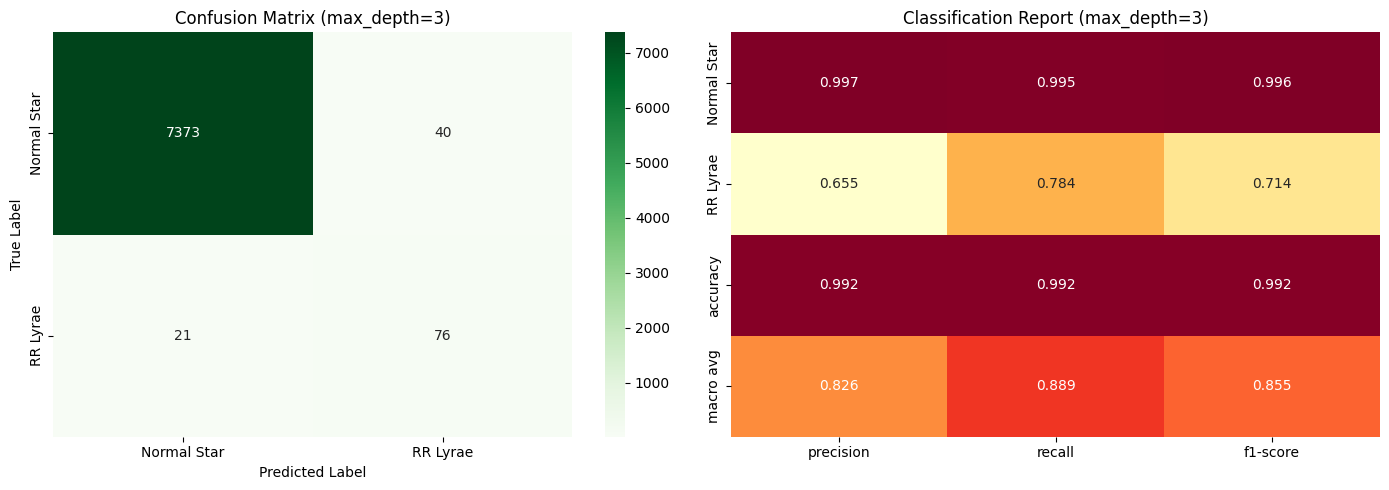


Detailed Results for Decision Tree (max_depth=3)
              precision    recall  f1-score   support

 Normal Star       1.00      0.99      1.00      7413
    RR Lyrae       0.66      0.78      0.71        97

    accuracy                           0.99      7510
   macro avg       0.83      0.89      0.85      7510
weighted avg       0.99      0.99      0.99      7510



In [24]:
# Train the best Decision Tree model and evaluate in detail
best_dt = DecisionTreeClassifier(max_depth=best_depth_cv, random_state=42, criterion='entropy')
best_dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = best_dt.predict(X_test)

# Calculate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0], 
            xticklabels=['Normal Star', 'RR Lyrae'],
            yticklabels=['Normal Star', 'RR Lyrae'])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title(f'Confusion Matrix (max_depth={best_depth_cv})')

# Classification Report
report_dt = classification_report(y_test, y_pred_dt, target_names=['Normal Star', 'RR Lyrae'], output_dict=True)
report_df_dt = pd.DataFrame(report_dt).transpose()
sns.heatmap(report_df_dt.iloc[:-1, :-1], annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], cbar=False)
axes[1].set_title(f'Classification Report (max_depth={best_depth_cv})')

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Detailed Results for Decision Tree (max_depth={best_depth_cv})")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_dt, target_names=['Normal Star', 'RR Lyrae']))

------

# Random Forest Classification

## Introduction to Random Forests

A **Random Forest** is an ensemble learning method that combines multiple decision trees to create a more powerful and robust classifier.

**How it works**:
1. Creates multiple decision trees, each trained on a random subset of the data (with replacement - "bootstrap samples")
2. Each tree also uses a random subset of features at each split
3. For predictions, each tree "votes" and the majority class wins
4. This ensemble approach reduces overfitting compared to a single tree

**Key Advantages**:
- **Reduces overfitting**: Averaging predictions from multiple trees is more robust than a single tree
- **Handles high-dimensional data**: Random feature selection at each split
- **Provides feature importance**: Shows which features are most important for classification
- **Parallelizable**: Trees can be built independently in parallel
- **Out-of-bag (OOB) error**: Can estimate performance without a separate test set

**Key Hyperparameters**:
- **n_estimators**: Number of trees in the forest (more trees = better, but slower)
- **max_depth**: Maximum depth of each tree (controls complexity of individual trees)
- **min_samples_split**: Minimum samples required to split a node (controls tree growth)

We'll use the same stellar dataset to classify stars as Normal or RR Lyrae using Random Forests.

### Step 1: Train Random Forests with Different Numbers of Trees

We'll test Random Forests with different numbers of trees (n_estimators) ranging from 1 to 200.

**Why n_estimators matters**:
- **n_estimators=1**: Just a single random tree, similar to a decision tree
- **n_estimators=10-50**: Good balance between performance and computational cost
- **n_estimators=100+**: More robust predictions, but diminishing returns
- **Very large n_estimators**: More stable predictions but slower training and prediction

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Test different numbers of trees
n_estimators_range = [10, 20, 50, 100, 150, 200, 500, 1000]
rf_train_accuracies = []
rf_test_accuracies = []

print("Training Random Forests with different numbers of trees...\n")

for n_trees in n_estimators_range:
    # Create and train the Random Forest classifier
    rf = RandomForestClassifier(n_estimators=n_trees, 
                                criterion='entropy',
                                max_depth=None, 
                                random_state=42, 
                                n_jobs=-1,
                                )
    rf.fit(X_train, y_train)
    
    # Calculate accuracies
    train_acc = balanced_accuracy_score(y_train, rf.predict(X_train))
    test_acc = balanced_accuracy_score(y_test, rf.predict(X_test))
    
    rf_train_accuracies.append(train_acc)
    rf_test_accuracies.append(test_acc)
    
    print(f"n_estimators={n_trees:3d} -> Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# Find the best n_estimators value
best_n_trees = n_estimators_range[np.argmax(rf_test_accuracies)]
best_rf_accuracy = max(rf_test_accuracies)

print(f"\n{'='*60}")
print(f"Best n_estimators value: {best_n_trees}")
print(f"Best test accuracy: {best_rf_accuracy:.4f}")
print(f"{'='*60}")

Training Random Forests with different numbers of trees...

n_estimators= 10 -> Train Acc: 0.9779, Test Acc: 0.8491
n_estimators= 20 -> Train Acc: 0.9922, Test Acc: 0.8696
n_estimators= 50 -> Train Acc: 0.9987, Test Acc: 0.8697
n_estimators=100 -> Train Acc: 1.0000, Test Acc: 0.8697
n_estimators=150 -> Train Acc: 1.0000, Test Acc: 0.8697
n_estimators=200 -> Train Acc: 1.0000, Test Acc: 0.8697
n_estimators=500 -> Train Acc: 1.0000, Test Acc: 0.8747
n_estimators=1000 -> Train Acc: 1.0000, Test Acc: 0.8747

Best n_estimators value: 500
Best test accuracy: 0.8747


### Step 2: Visualize the Effect of Number of Trees on Performance

This plot shows how the number of trees affects model performance:
- **Blue line with circles**: Training accuracy (usually stays high or reaches 100%)
- **Orange line with squares**: Testing accuracy (what we care about most)

Key observations:
- Performance typically improves quickly as we add more trees
- After a certain point, adding more trees shows diminishing returns
- Unlike single decision trees, Random Forests typically don't overfit as much

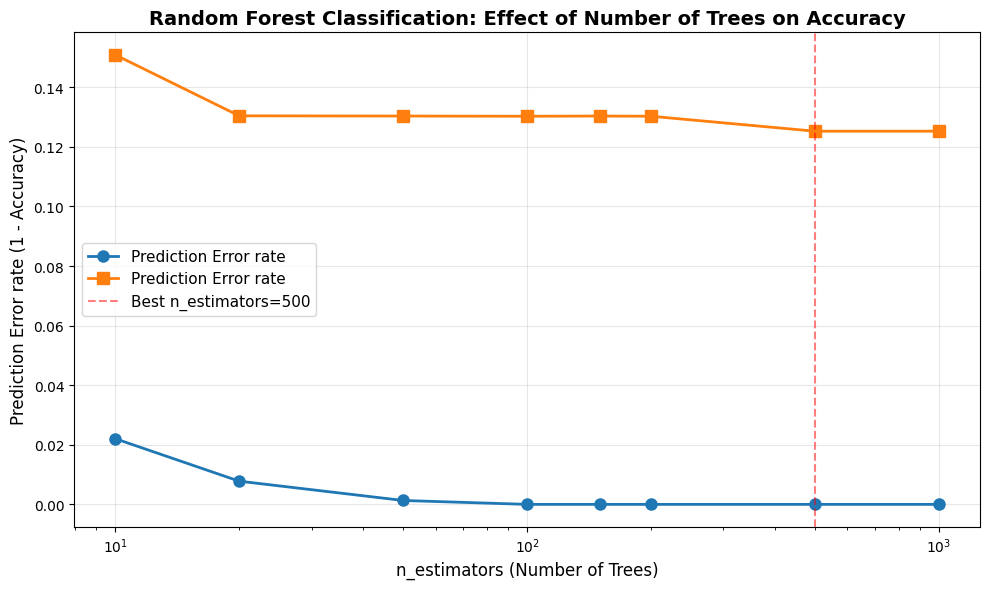


Best n_estimators value: 500
Best test accuracy: 0.8747


In [26]:
# Visualize how n_estimators affects Random Forest performance
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, np.ones(len(rf_train_accuracies))-rf_train_accuracies, marker='o', label='Prediction Error rate', linewidth=2, markersize=8)
plt.plot(n_estimators_range, np.ones(len(rf_test_accuracies))-rf_test_accuracies, marker='s', label='Prediction Error rate', linewidth=2, markersize=8)
plt.axvline(x=best_n_trees, color='red', linestyle='--', alpha=0.5, label=f'Best n_estimators={best_n_trees}')
plt.xlabel('n_estimators (Number of Trees)', fontsize=12)
plt.ylabel('Prediction Error rate (1 - Accuracy)', fontsize=12)
plt.title('Random Forest Classification: Effect of Number of Trees on Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_estimators_range)
# plt.ylim([0.8, 1.01])
plt.xscale('log')
# plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"\nBest n_estimators value: {best_n_trees}")
print(f"Best test accuracy: {best_rf_accuracy:.4f}")

### Step 3: Detailed Evaluation of the Best Random Forest Model

The confusion matrix and classification report provide detailed insights into the model's performance.

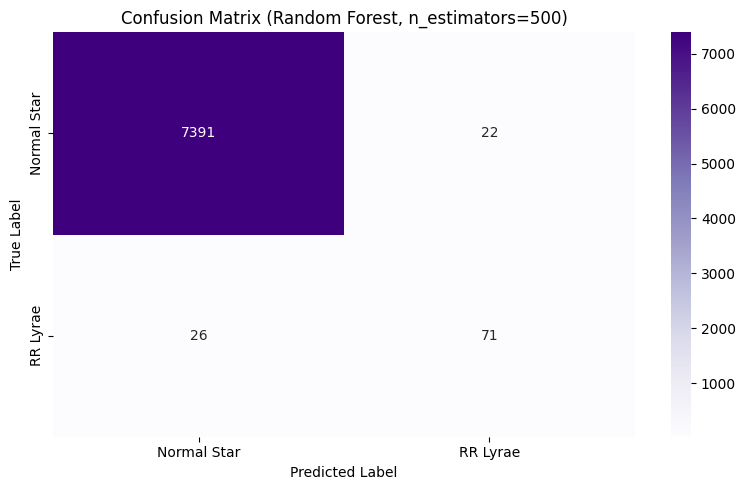


Detailed Results for Random Forest (n_estimators=500)
              precision    recall  f1-score   support

 Normal Star       1.00      1.00      1.00      7413
    RR Lyrae       0.76      0.73      0.75        97

    accuracy                           0.99      7510
   macro avg       0.88      0.86      0.87      7510
weighted avg       0.99      0.99      0.99      7510



In [28]:
# Train the best Random Forest model and evaluate in detail
best_rf = RandomForestClassifier(n_estimators=best_n_trees, max_depth=None, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = best_rf.predict(X_test)

# Calculate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=axes, 
            xticklabels=['Normal Star', 'RR Lyrae'],
            yticklabels=['Normal Star', 'RR Lyrae'])
axes.set_ylabel('True Label')
axes.set_xlabel('Predicted Label')
axes.set_title(f'Confusion Matrix (Random Forest, n_estimators={best_n_trees})')

# Classification Report
report_rf = classification_report(y_test, y_pred_rf, target_names=['Normal Star', 'RR Lyrae'], output_dict=True)
report_df_rf = pd.DataFrame(report_rf).transpose()
# sns.heatmap(report_df_rf.iloc[:-1, :-1], annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], cbar=False)
# axes[1].set_title(f'Classification Report (Random Forest, n_estimators={best_n_trees})')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"Detailed Results for Random Forest (n_estimators={best_n_trees})")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_rf, target_names=['Normal Star', 'RR Lyrae']))

### Step 4: Feature Importance Analysis

One of the key advantages of Random Forests is that they provide **feature importance** - a measure of how much each feature contributes to the classification.

The importance is based on how much each feature decreases the impurity (Gini or entropy) across all trees in the forest. Features that are more important for separating the classes will have higher importance scores.


Feature Importances in the Random Forest:
--------------------------------------------------
1. g-r   : 0.3115
2. u-g   : 0.2874
3. r-i   : 0.2448
4. i-z   : 0.1563


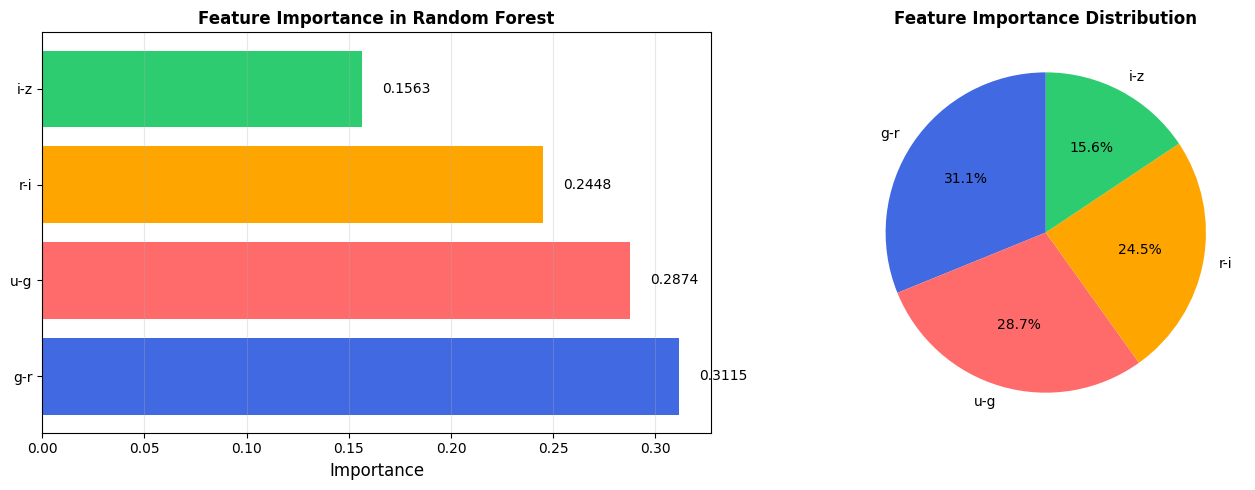


Interpretation:
• Features with higher importance are more useful for distinguishing star types
• This analysis can guide feature selection in real applications
• In astronomy, these color indices have physical meaning related to stellar properties


In [29]:
# Extract feature importances
feature_importance = best_rf.feature_importances_
feature_names = ['u-g', 'g-r', 'r-i', 'i-z']

# Sort features by importance
indices = np.argsort(feature_importance)[::-1]

# Print feature importances
print("\nFeature Importances in the Random Forest:")
print("-" * 50)
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]:6s}: {feature_importance[idx]:.4f}")

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of feature importance
colors = ['#FF6B6B', '#4169E1', '#FFA500', '#2ECC71']
sorted_colors = [colors[i] for i in indices]

axes[0].barh(range(len(indices)), feature_importance[indices], color=sorted_colors)
axes[0].set_yticks(range(len(indices)))
axes[0].set_yticklabels([feature_names[i] for i in indices])
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Feature Importance in Random Forest', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, v in enumerate(feature_importance[indices]):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Pie chart of feature importance
axes[1].pie(feature_importance[indices], labels=[feature_names[i] for i in indices], 
            autopct='%1.1f%%', colors=sorted_colors, startangle=90)
axes[1].set_title('Feature Importance Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("• Features with higher importance are more useful for distinguishing star types")
print("• This analysis can guide feature selection in real applications")
print("• In astronomy, these color indices have physical meaning related to stellar properties")

### Step 5: Cross Validation Evaluation of Random Forest

Let's use k-fold cross validation to robustly evaluate the Random Forest model with different numbers of trees.

In [33]:
# 5-fold cross validation for Random Forest
rf_cv_mean_accuracies = []
rf_cv_std_accuracies = []

print(f"Performing {n_splits}-Fold Cross Validation for Random Forest...\n")

for n_trees in n_estimators_range:
    # Create Random Forest with this number of estimators
    rf = RandomForestClassifier(n_estimators=n_trees, max_depth=None, random_state=42, n_jobs=-1, criterion='entropy')
    
    # Perform cross validation
    cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='balanced_accuracy')
    
    # Store mean and standard deviation
    rf_cv_mean_accuracies.append(cv_scores.mean())
    rf_cv_std_accuracies.append(cv_scores.std())
    
    print(f"n_estimators={n_trees:3d}: CV Accuracy = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Find the best n_estimators using cross validation
best_n_trees_cv = n_estimators_range[np.argmax(rf_cv_mean_accuracies)]
best_rf_cv_accuracy = max(rf_cv_mean_accuracies)
best_rf_cv_std = rf_cv_std_accuracies[np.argmax(rf_cv_mean_accuracies)]

print(f"\n{'='*60}")
print(f"Best n_estimators (by Cross Validation): {best_n_trees_cv}")
print(f"Cross Validation Accuracy: {best_rf_cv_accuracy:.4f} ± {best_rf_cv_std:.4f}")
print(f"{'='*60}")

Performing 5-Fold Cross Validation for Random Forest...

n_estimators= 10: CV Accuracy = 0.8450 ± 0.0234
n_estimators= 20: CV Accuracy = 0.8503 ± 0.0195
n_estimators= 50: CV Accuracy = 0.8581 ± 0.0310
n_estimators=100: CV Accuracy = 0.8576 ± 0.0289
n_estimators=150: CV Accuracy = 0.8557 ± 0.0305
n_estimators=200: CV Accuracy = 0.8546 ± 0.0291
n_estimators=500: CV Accuracy = 0.8591 ± 0.0276
n_estimators=1000: CV Accuracy = 0.8590 ± 0.0280

Best n_estimators (by Cross Validation): 500
Cross Validation Accuracy: 0.8591 ± 0.0276


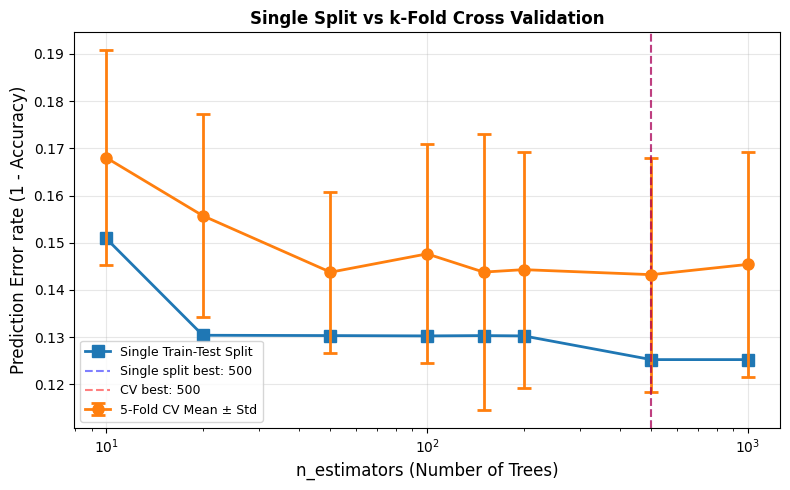

In [31]:
# Visualize cross validation results
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

# Plot 2: Compare single split vs k-fold CV
axes.plot(n_estimators_range, 
          np.ones(len(rf_test_accuracies))-rf_test_accuracies, 
          marker='s', 
          label='Single Train-Test Split', 
          linewidth=2, 
          markersize=8)
axes.errorbar(n_estimators_range, 
              np.ones(len(rf_cv_mean_accuracies))-rf_cv_mean_accuracies, 
              yerr=rf_cv_std_accuracies, 
              marker='o', 
              linestyle='-', 
              linewidth=2, 
              markersize=8, 
              capsize=5, 
              capthick=2, 
              label='5-Fold CV Mean ± Std')

axes.axvline(x=best_n_trees, 
             color='blue', 
             linestyle='--', 
             alpha=0.5, 
             label=f'Single split best: {best_n_trees}')
axes.axvline(x=best_n_trees_cv, 
             color='red', 
             linestyle='--', 
             alpha=0.5, 
             label=f'CV best: {best_n_trees_cv}')

axes.set_xlabel('n_estimators (Number of Trees)', fontsize=12)
axes.set_ylabel('Prediction Error rate (1 - Accuracy)', fontsize=12)
axes.set_title('Single Split vs k-Fold Cross Validation', fontsize=12, fontweight='bold')
axes.set_xticks(n_estimators_range)
axes.grid(True, alpha=0.3)
axes.legend(fontsize=9)
# axes.set_ylim([0.85, 1.01])
axes.set_xscale('log')

plt.tight_layout()
plt.show()

## Step 6. Grid Search for Hyperparameter Tuning

### What is Grid Search?

**Grid Search** is a systematic approach to hyperparameter tuning that exhaustively searches through all combinations of specified hyperparameter values. It's called "grid" because you define a grid of values for each parameter, and the search tests all possible combinations.

### How Grid Search Works

1. **Define Parameter Grid**: Specify ranges or lists of values for each hyperparameter
2. **Create All Combinations**: Generate all possible combinations of parameter values
3. **Cross Validation**: For each combination, evaluate the model using k-fold cross validation
4. **Select Best**: Choose the combination with the best cross-validation score
5. **Final Training**: Train a final model using the best parameters on the full training set

### Key Hyperparameters for Random Forest

- **n_estimators**: Number of decision trees in the forest (more ≠ always better)
- **max_depth**: Maximum depth of each tree (controls complexity)
- **min_samples_split**: Minimum samples required to split a node (prevents small splits)
- **min_samples_leaf**: Minimum samples required at a leaf node (controls final predictions)
- **max_features**: Number of features considered at each split ('sqrt' or 'log2' are common)
- **bootstrap**: Whether to use bootstrap samples for training trees

### Trade-offs in Hyperparameter Selection

| Parameter | Increasing Value | Effect |
|-----------|------------------|--------|
| n_estimators | More trees | Better performance but slower |
| max_depth | Deeper trees | More complex model, risk of overfitting |
| min_samples_split | Higher values | Simpler trees, less overfitting |
| min_samples_leaf | Higher values | Simpler leaf nodes, less overfitting |
| max_features | More features | More complex splits, potentially better patterns |
| bootstrap | True | More diversity, less overfitting |

### Why Use Grid Search?

1. **Finds Parameter Interactions**: Some parameters work better together
2. **Systematic Exploration**: Ensures you don't miss good combinations
3. **Robust Evaluation**: Cross validation gives stable performance estimates
4. **Reproducible**: Results can be replicated and documented
5. **Scalable**: Can be parallelized for faster computation

### When to Use Grid Search vs Other Methods

- **Grid Search**: Good for small to medium parameter spaces, when you have computational resources
- **Random Search**: Better for large parameter spaces, samples random combinations
- **Bayesian Optimization**: For complex spaces where past results guide future searches
- **Manual Tuning**: Only when you have strong prior knowledge about good parameters

In [ ]:
# Grid Search for Random Forest Hyperparameter Optimization
# This performs an exhaustive search over specified parameter values for a Random Forest classifier

# Define the parameter grid to search over
param_grid = {
    'n_estimators': [100, 250, 500],           # Number of trees
    'max_depth': [3, 5, 10, 15],            # Maximum tree depth (None = unlimited)
    'min_samples_split': [5, 10],               # Minimum samples to split a node
    'max_features': ['sqrt', 'log2'],              # Number of features to consider at each split
    'bootstrap': [True]                     # Whether to use bootstrap samples
}

print("="*70)
print("RANDOM FOREST HYPERPARAMETER GRID SEARCH")
print("="*70)
print(f"\nParameter Grid:")
for param, values in param_grid.items():
    print(f"  {param:20s}: {values}")

print(f"\nTotal combinations to test: {np.prod([len(v) for v in param_grid.values()])}")
print(f"Using 5-fold Cross Validation for robust evaluation")
print(f"\nStarting Grid Search (this may take a minute or two)...\n")

# Create the base Random Forest classifier
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1, criterion='entropy')

# Perform Grid Search with Cross Validation
grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=kf,  # Use the same 5-fold cross validation as before
    scoring='balanced_accuracy',  # Use balanced accuracy for imbalanced data
    n_jobs=-1,  # Use all available processors
    verbose=2  # Print progress
)

# Fit the grid search
grid_search.fit(X_train, y_train)

print(f"\n{'='*70}")
print("GRID SEARCH RESULTS")
print(f"{'='*70}")
print(f"\nBest Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:20s}: {value}")

print(f"\nBest Cross Validation Score: {grid_search.best_score_:.4f}")
print(f"{'='*70}\n")

# Extract the best model
best_rf_grid = grid_search.best_estimator_

# Test the best model on the test set
y_pred_rf_grid = best_rf_grid.predict(X_test)
test_accuracy_grid = balanced_accuracy_score(y_test, y_pred_rf_grid)
train_accuracy_grid = balanced_accuracy_score(y_train, best_rf_grid.predict(X_train))

print(f"\nPerformance of Best Model (from Grid Search):")
print(f"  Training Set Accuracy: {train_accuracy_grid:.4f}")
print(f"  Testing Set Accuracy:  {test_accuracy_grid:.4f}")
print(f"  Overfitting Gap:       {train_accuracy_grid - test_accuracy_grid:.4f}")

RANDOM FOREST HYPERPARAMETER GRID SEARCH

Parameter Grid:
  n_estimators        : [100, 250, 500]
  max_depth           : [3, 5, 10, 15, None]
  min_samples_split   : [5, 10]
  max_features        : ['sqrt', 'log2']
  bootstrap           : [True]

Total combinations to test: 60
Using 5-fold Cross Validation for robust evaluation

Starting Grid Search (this may take a minute or two)...

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END bootstrap=True, max_depth=3, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=3, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=3, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=3, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=3, max_features=sqrt, min_samples_split=5, n_estimator

In [35]:
# Analyze Grid Search Results
# Extract results into a dataframe for easier analysis
results_df = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns and sort by mean test score
results_summary = results_df[[
    'param_n_estimators',
    'param_max_depth', 
    'param_min_samples_split',
    'param_max_features',
    'param_bootstrap',
    'mean_test_score',
    'std_test_score',
]].copy()

results_summary = results_summary.sort_values('mean_test_score', ascending=False)

print("\n" + "="*100)
print("TOP 10 HYPERPARAMETER COMBINATIONS")
print("="*100)
print(results_summary.head(10).to_string(index=False))
print("="*100)

# Analyze the impact of individual parameters on performance
print("\n" + "="*100)
print("IMPACT OF INDIVIDUAL PARAMETERS ON CV PERFORMANCE")
print("="*100)

for param in param_grid.keys():
    param_col = f'param_{param}'
    impact = results_df.groupby(param_col)['mean_test_score'].agg(['mean', 'std', 'count'])
    impact = impact.sort_values('mean', ascending=False)
    
    print(f"\n{param}:")
    print("-" * 70)
    print(impact.to_string())
    print(f"Best value: {impact.index[0]}")
    print(f"Performance difference: {impact['mean'].iloc[0] - impact['mean'].iloc[-1]:.4f}")


TOP 10 HYPERPARAMETER COMBINATIONS
 param_n_estimators param_max_depth  param_min_samples_split param_max_features  param_bootstrap  mean_test_score  std_test_score
                250              10                       10               sqrt             True         0.855020        0.030595
                250              10                       10               log2             True         0.855020        0.030595
                250              10                        5               sqrt             True         0.854378        0.025333
                250              10                        5               log2             True         0.854378        0.025333
                500              10                       10               sqrt             True         0.853614        0.030853
                500              10                       10               log2             True         0.853614        0.030853
                500              10                   

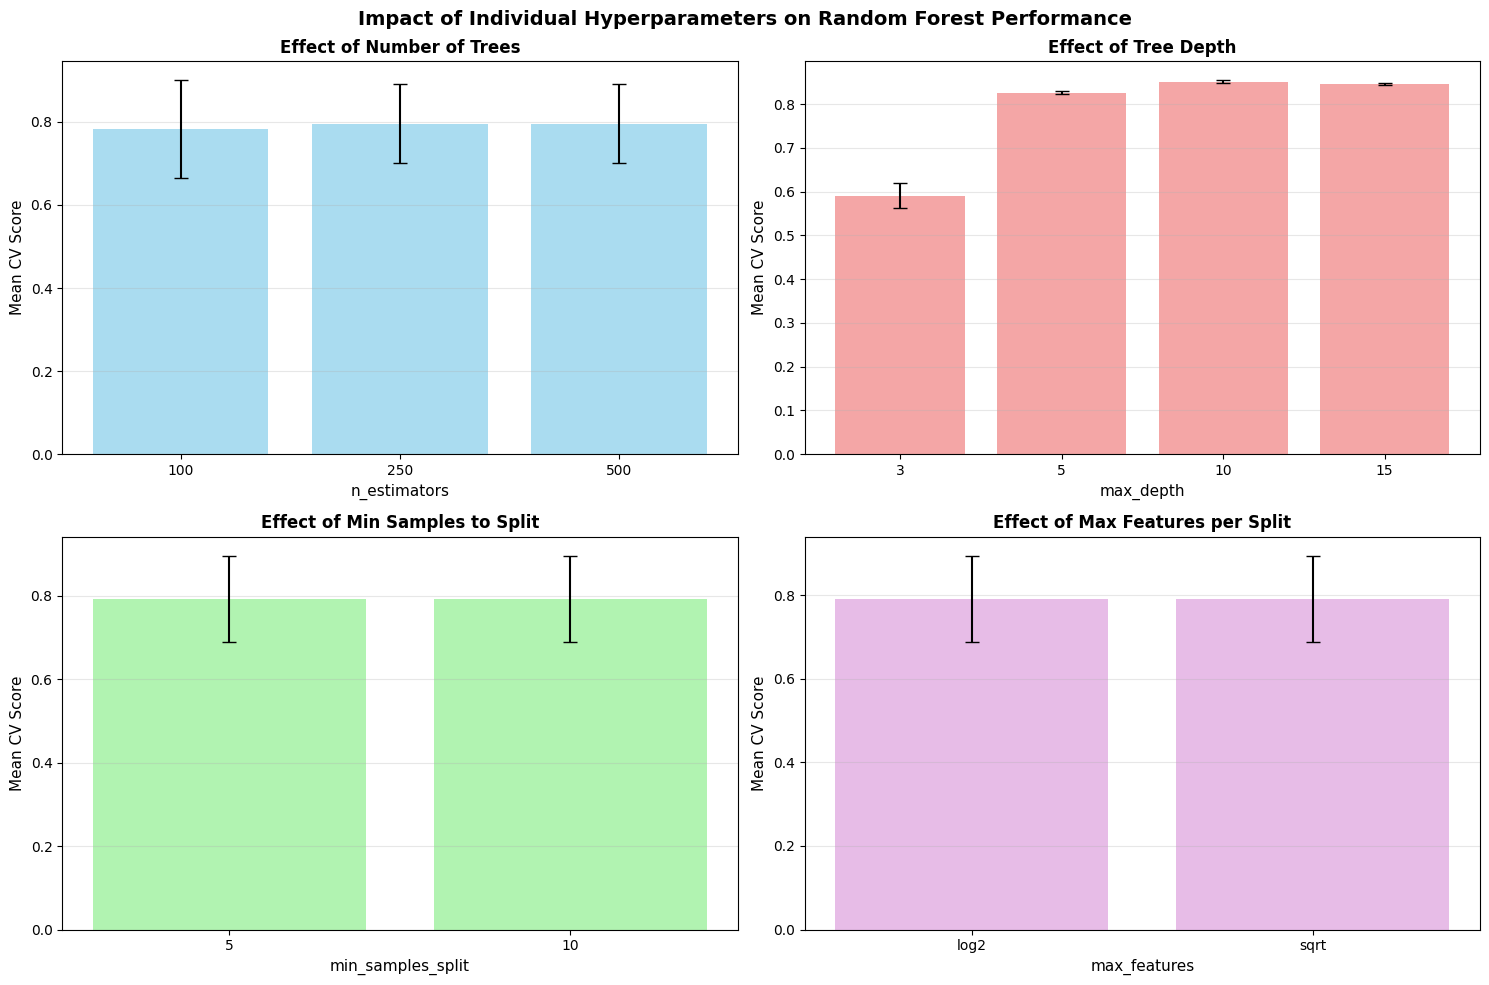


Parameter Impact Analysis Complete!


In [36]:
# Visualize Parameter Impact
# Create visualizations for key parameters

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Impact of Individual Hyperparameters on Random Forest Performance', 
             fontsize=14, fontweight='bold')

# Plot 1: n_estimators
n_est_impact = results_df.groupby('param_n_estimators')['mean_test_score'].agg(['mean', 'std'])
axes[0, 0].bar(range(len(n_est_impact)), n_est_impact['mean'], 
               yerr=n_est_impact['std'], capsize=5, alpha=0.7, color='skyblue')
axes[0, 0].set_xticks(range(len(n_est_impact)))
axes[0, 0].set_xticklabels(n_est_impact.index.astype(int))
axes[0, 0].set_xlabel('n_estimators', fontsize=11)
axes[0, 0].set_ylabel('Mean CV Score', fontsize=11)
axes[0, 0].set_title('Effect of Number of Trees', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: max_depth
max_depth_impact = results_df.groupby('param_max_depth')['mean_test_score'].agg(['mean', 'std'])
axes[0, 1].bar(range(len(max_depth_impact)), max_depth_impact['mean'], 
               yerr=max_depth_impact['std'], capsize=5, alpha=0.7, color='lightcoral')
axes[0, 1].set_xticks(range(len(max_depth_impact)))
axes[0, 1].set_xticklabels([str(x) if x is not None else 'None' for x in max_depth_impact.index])
axes[0, 1].set_xlabel('max_depth', fontsize=11)
axes[0, 1].set_ylabel('Mean CV Score', fontsize=11)
axes[0, 1].set_title('Effect of Tree Depth', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: min_samples_split
min_split_impact = results_df.groupby('param_min_samples_split')['mean_test_score'].agg(['mean', 'std'])
axes[1, 0].bar(range(len(min_split_impact)), min_split_impact['mean'], 
               yerr=min_split_impact['std'], capsize=5, alpha=0.7, color='lightgreen')
axes[1, 0].set_xticks(range(len(min_split_impact)))
axes[1, 0].set_xticklabels(min_split_impact.index.astype(int))
axes[1, 0].set_xlabel('min_samples_split', fontsize=11)
axes[1, 0].set_ylabel('Mean CV Score', fontsize=11)
axes[1, 0].set_title('Effect of Min Samples to Split', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 5: max_features
max_feat_impact = results_df.groupby('param_max_features')['mean_test_score'].agg(['mean', 'std'])
axes[1, 1].bar(range(len(max_feat_impact)), max_feat_impact['mean'], 
               yerr=max_feat_impact['std'], capsize=5, alpha=0.7, color='plum')
axes[1, 1].set_xticks(range(len(max_feat_impact)))
axes[1, 1].set_xticklabels(max_feat_impact.index.astype(str))
axes[1, 1].set_xlabel('max_features', fontsize=11)
axes[1, 1].set_ylabel('Mean CV Score', fontsize=11)
axes[1, 1].set_title('Effect of Max Features per Split', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nParameter Impact Analysis Complete!")

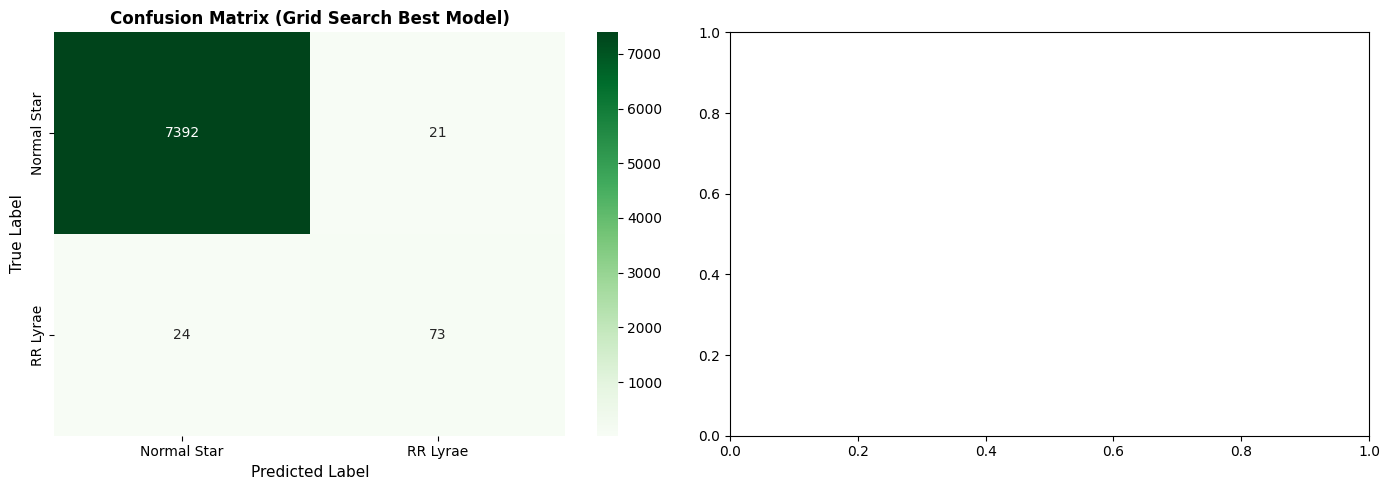


Detailed Results - Best Model from Grid Search
              precision    recall  f1-score   support

 Normal Star       1.00      1.00      1.00      7413
    RR Lyrae       0.78      0.75      0.76        97

    accuracy                           0.99      7510
   macro avg       0.89      0.87      0.88      7510
weighted avg       0.99      0.99      0.99      7510


Additional Metrics:
  Balanced Accuracy: 0.8749
  F1-Score:          0.9940
  RR Lyrae Precision: 0.7766
  RR Lyrae Recall:    0.7526


In [37]:
# Detailed Evaluation of Best Model from Grid Search
# Create confusion matrix and classification report

cm_grid = confusion_matrix(y_test, y_pred_rf_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm_grid, annot=True, fmt='d', cmap='Greens', ax=axes[0], 
            xticklabels=['Normal Star', 'RR Lyrae'],
            yticklabels=['Normal Star', 'RR Lyrae'])
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_title(f'Confusion Matrix (Grid Search Best Model)', fontsize=12, fontweight='bold')

# Classification Report
report_grid = classification_report(y_test, y_pred_rf_grid, 
                                    target_names=['Normal Star', 'RR Lyrae'], 
                                    output_dict=True)
report_df_grid = pd.DataFrame(report_grid).transpose()
# sns.heatmap(report_df_grid.iloc[:-1, :-1], annot=True, fmt='.3f', cmap='YlOrRd', 
#             ax=axes[1], cbar=False)
# axes[1].set_title(f'Classification Report (Grid Search Best Model)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"Detailed Results - Best Model from Grid Search")
print(f"{'='*70}")
print(classification_report(y_test, y_pred_rf_grid, 
                            target_names=['Normal Star', 'RR Lyrae']))

# Calculate additional metrics
rf_precision_grid = precision_score(y_test, y_pred_rf_grid, pos_label=1.0)
rf_recall_grid = recall_score(y_test, y_pred_rf_grid, pos_label=1.0)
rf_f1_grid = f1_score(y_test, y_pred_rf_grid, average='weighted')

print(f"\nAdditional Metrics:")
print(f"  Balanced Accuracy: {test_accuracy_grid:.4f}")
print(f"  F1-Score:          {rf_f1_grid:.4f}")
print(f"  RR Lyrae Precision: {rf_precision_grid:.4f}")
print(f"  RR Lyrae Recall:    {rf_recall_grid:.4f}")

------

# XGBoost Classification

## Introduction to XGBoost (Extreme Gradient Boosting)

**XGBoost** is a highly optimized gradient boosting framework that has become one of the most popular machine learning algorithms for classification and regression tasks.

**How it works**:
1. Builds an ensemble of decision trees sequentially, with each new tree correcting errors made by previous trees
2. Uses gradient descent to minimize a loss function
3. Applies regularization to prevent overfitting (L1 and L2 penalties)
4. Features parallel and distributed computing for speed
5. Uses a technique called "shrinkage" (learning rate) to gradually improve predictions

**Key Advantages**:
- **Superior Performance**: Often achieves state-of-the-art results on classification and regression tasks
- **Handles Imbalanced Data**: Built-in support for `scale_pos_weight` to handle class imbalance
- **Feature Importance**: Provides detailed feature importance rankings
- **Regularization**: L1/L2 regularization reduces overfitting
- **Speed**: Highly optimized and can be parallelized
- **Stability**: More stable predictions than single decision trees

**Key Hyperparameters**:
- **n_estimators**: Number of boosting rounds (trees to build)
- **max_depth**: Maximum depth of each tree (typically 3-10 for XGBoost)
- **learning_rate**: Shrinkage parameter controlling how much each tree contributes (0.01-0.3)
- **min_child_weight**: Minimum sum of weights needed in a child node
- **subsample**: Fraction of samples used for building each tree
- **colsample_bytree**: Fraction of features used for building each tree
- **scale_pos_weight**: Weight for imbalanced classes (important for our RR Lyrae problem!)

We'll optimize these hyperparameters using k-fold cross validation on the stellar classification task.

### Step 1: Hyperparameter Tuning Using k-Fold Cross Validation

XGBoost has many hyperparameters. We'll optimize the most important ones using k-fold cross validation:
- **max_depth**: Controls tree complexity (3-10)
- **learning_rate**: Controls how fast the model learns (0.01-0.3)
- **n_estimators**: Number of boosting rounds (50-500)

We'll test combinations of these and track balanced accuracy to find the best configuration.

In [38]:
# Import XGBoost
import xgboost as xgb

# Calculate scale_pos_weight for the imbalanced dataset
# This penalizes misclassifying the minority class (RR Lyrae)
class_counts = y.value_counts()
scale_pos_weight = class_counts[0] / class_counts[1]

print(f"Class counts: {class_counts.to_dict()}")
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")
print(f"This means: penalize RR Lyrae misclassification {scale_pos_weight:.1f}x more than Normal star misclassification\n")

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 250, 500, 1000]
}

# Base XGBoost classifier with scale_pos_weight to handle imbalance
xgb_base = xgb.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    verbosity=0,
    eval_metric='logloss'
)

# Grid search with k-fold cross validation using balanced_accuracy
print("Performing Grid Search with 5-Fold Cross Validation...")
print("This may take a minute...\n")

grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=kf,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Get results
print(f"\n{'='*70}")
print("GRID SEARCH RESULTS")
print(f"{'='*70}")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (Precision): {grid_search.best_score_:.4f}")
print(f"{'='*70}\n")

# Extract best parameters
best_xgb_params = grid_search.best_params_
best_xgb = grid_search.best_estimator_

Class counts: {0.0: 37063, 1.0: 483}
scale_pos_weight for XGBoost: 76.73
This means: penalize RR Lyrae misclassification 76.7x more than Normal star misclassification

Performing Grid Search with 5-Fold Cross Validation...
This may take a minute...

Fitting 5 folds for each of 48 candidates, totalling 240 fits

GRID SEARCH RESULTS
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best CV Score (Precision): 0.9758



Top 10 Hyperparameter Combinations:
--------------------------------------------------------------------------------
max_depth=3 | lr=0.01 | n_est=100 | Score: 0.9758 ± 0.0060
max_depth=3 | lr=0.01 | n_est=250 | Score: 0.9751 ± 0.0111
max_depth=3 | lr=0.1 | n_est=100 | Score: 0.9746 ± 0.0135
max_depth=3 | lr=0.01 | n_est=500 | Score: 0.9742 ± 0.0133
max_depth=3 | lr=0.01 | n_est=1000 | Score: 0.9731 ± 0.0133
max_depth=5 | lr=0.01 | n_est=100 | Score: 0.9689 ± 0.0152
max_depth=3 | lr=0.1 | n_est=250 | Score: 0.9688 ± 0.0145
max_depth=5 | lr=0.01 | n_est=250 | Score: 0.9662 ± 0.0201
max_depth=3 | lr=0.3 | n_est=100 | Score: 0.9631 ± 0.0201
max_depth=5 | lr=0.01 | n_est=500 | Score: 0.9624 ± 0.0178


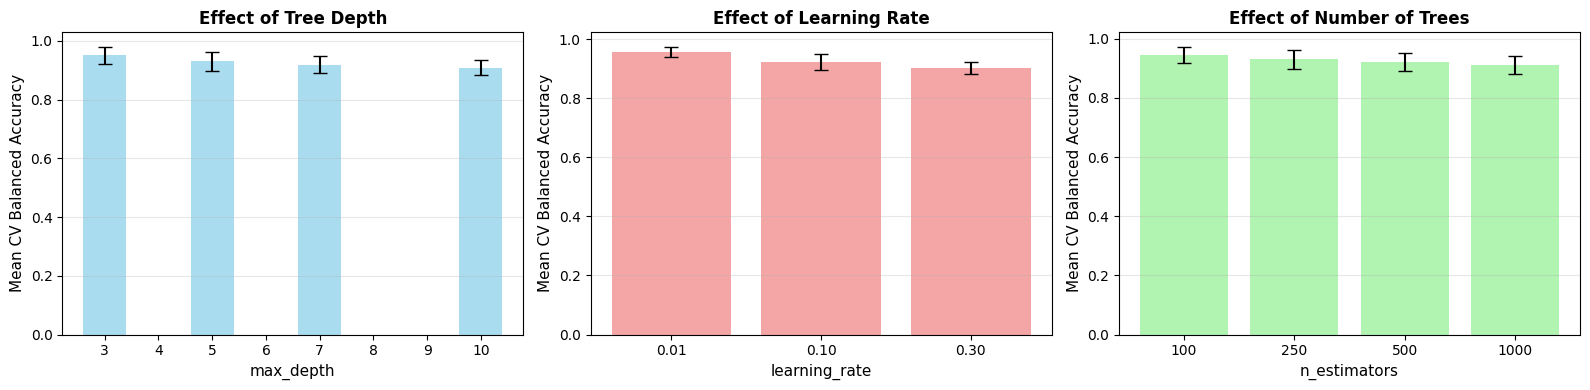

In [39]:
# Visualize grid search results
results_df = pd.DataFrame(grid_search.cv_results_)
results_summary = results_df[['param_max_depth', 'param_learning_rate', 'param_n_estimators', 
                              'mean_test_score', 'std_test_score']].copy()
results_summary = results_summary.sort_values('mean_test_score', ascending=False)

print("Top 10 Hyperparameter Combinations:")
print("-" * 80)
for idx, row in results_summary.head(10).iterrows():
    print(f"max_depth={int(row['param_max_depth'])} | lr={row['param_learning_rate']} | "
          f"n_est={int(row['param_n_estimators'])} | Score: {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")

# Create visualization of parameter effects
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Effect of max_depth
depth_summary = results_df.groupby('param_max_depth')['mean_test_score'].agg(['mean', 'std'])
axes[0].bar(depth_summary.index, depth_summary['mean'], yerr=depth_summary['std'], 
            alpha=0.7, capsize=5, color='skyblue')
axes[0].set_xlabel('max_depth', fontsize=11)
axes[0].set_ylabel('Mean CV Balanced Accuracy', fontsize=11)
axes[0].set_title('Effect of Tree Depth', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Effect of learning_rate
lr_summary = results_df.groupby('param_learning_rate')['mean_test_score'].agg(['mean', 'std'])
axes[1].bar(range(len(lr_summary)), lr_summary['mean'], yerr=lr_summary['std'], 
            alpha=0.7, capsize=5, color='lightcoral')
axes[1].set_xlabel('learning_rate', fontsize=11)
axes[1].set_ylabel('Mean CV Balanced Accuracy', fontsize=11)
axes[1].set_title('Effect of Learning Rate', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(len(lr_summary)))
axes[1].set_xticklabels([f"{x:.2f}" for x in lr_summary.index], rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

# Effect of n_estimators
est_summary = results_df.groupby('param_n_estimators')['mean_test_score'].agg(['mean', 'std'])
axes[2].bar(range(len(est_summary)), est_summary['mean'], yerr=est_summary['std'], 
            alpha=0.7, capsize=5, color='lightgreen')
axes[2].set_xlabel('n_estimators', fontsize=11)
axes[2].set_ylabel('Mean CV Balanced Accuracy', fontsize=11)
axes[2].set_title('Effect of Number of Trees', fontsize=12, fontweight='bold')
axes[2].set_xticks(range(len(est_summary)))
axes[2].set_xticklabels(est_summary.index.astype(int), rotation=0)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Step 2: Detailed Evaluation of the Best XGBoost Model

Now we evaluate the optimized XGBoost model on the test set using our comprehensive metrics.

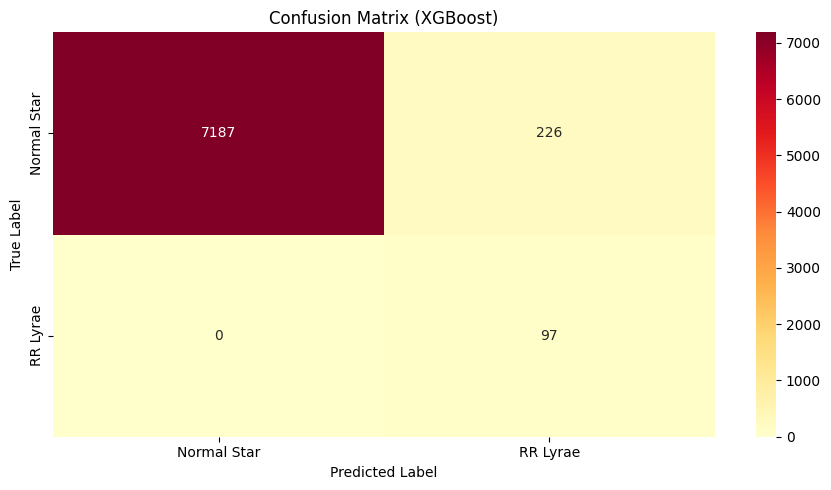


Detailed Results for XGBoost
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

 Normal Star       1.00      0.97      0.98      7413
    RR Lyrae       0.30      1.00      0.46        97

    accuracy                           0.97      7510
   macro avg       0.65      0.98      0.72      7510
weighted avg       0.99      0.97      0.98      7510


XGBoost Performance Summary:
  Balanced Accuracy: 0.9848
  F1-Score:          0.4619
  RR Lyrae Precision: 0.3003
  RR Lyrae Recall:    1.0000


In [40]:
# Make predictions with the best XGBoost model
y_pred_xgb = best_xgb.predict(X_test)

# Calculate confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot confusion matrix
fig, axes = plt.subplots(1, 1, figsize=(9, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='YlOrRd', ax=axes, 
            xticklabels=['Normal Star', 'RR Lyrae'],
            yticklabels=['Normal Star', 'RR Lyrae'])
axes.set_ylabel('True Label')
axes.set_xlabel('Predicted Label')
axes.set_title(f'Confusion Matrix (XGBoost)')

# Classification Report
report_xgb = classification_report(y_test, y_pred_xgb, target_names=['Normal Star', 'RR Lyrae'], output_dict=True)
report_df_xgb = pd.DataFrame(report_xgb).transpose()

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"Detailed Results for XGBoost")
print(f"Best Parameters: {best_xgb_params}")
print(f"{'='*70}")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal Star', 'RR Lyrae']))

# Calculate metrics for comparison
xgb_balanced_acc = balanced_accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, pos_label=1.0)
xgb_precision = precision_score(y_test, y_pred_xgb, pos_label=1.0)
xgb_recall = recall_score(y_test, y_pred_xgb, pos_label=1.0)

print(f"\nXGBoost Performance Summary:")
print(f"  Balanced Accuracy: {xgb_balanced_acc:.4f}")
print(f"  F1-Score:          {xgb_f1:.4f}")
print(f"  RR Lyrae Precision: {xgb_precision:.4f}")
print(f"  RR Lyrae Recall:    {xgb_recall:.4f}")

### Step 3: Feature Importance Analysis for XGBoost

XGBoost provides detailed feature importance information showing how many times each feature was used for splitting across all trees.


Feature Importances in XGBoost:
--------------------------------------------------
1. g-r   : 0.9275
2. u-g   : 0.0437
3. i-z   : 0.0148
4. r-i   : 0.0139


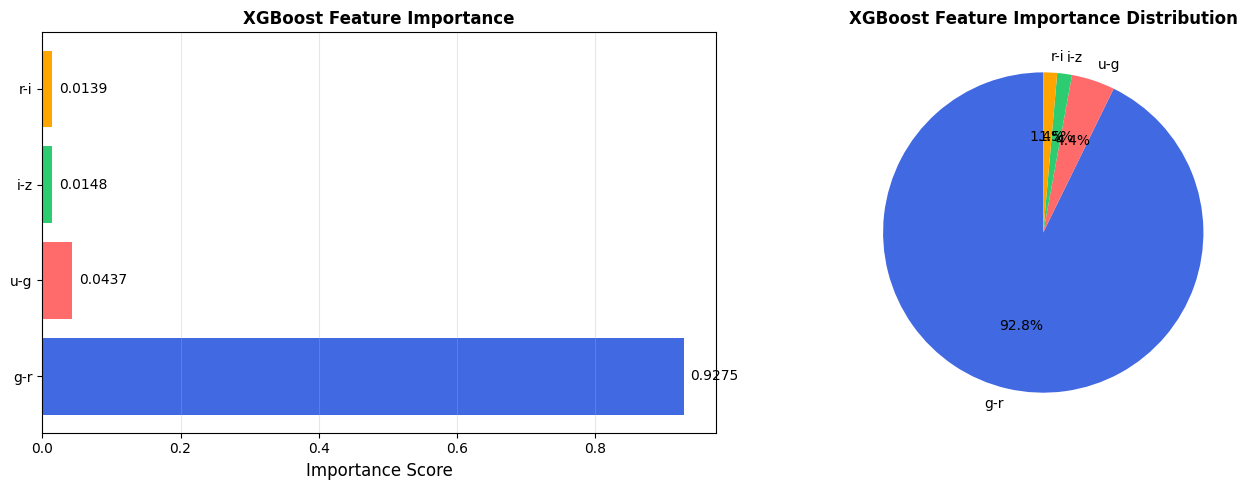


Interpretation:
• XGBoost feature importance is based on the number of times features are used for splitting
• More important features are better at discriminating between Normal stars and RR Lyrae
• Compare these importances with Random Forest to see if the models agree


In [41]:
# Extract feature importances from XGBoost
feature_names = ['u-g', 'g-r', 'r-i', 'i-z']
xgb_feature_importance = best_xgb.feature_importances_

# Sort by importance
xgb_indices = np.argsort(xgb_feature_importance)[::-1]

# Print feature importances
print("\nFeature Importances in XGBoost:")
print("-" * 50)
for i, idx in enumerate(xgb_indices):
    print(f"{i+1}. {feature_names[idx]:6s}: {xgb_feature_importance[idx]:.4f}")

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of feature importance
colors = ['#FF6B6B', '#4169E1', '#FFA500', '#2ECC71']
sorted_colors = [colors[i] for i in xgb_indices]

axes[0].barh(range(len(xgb_indices)), xgb_feature_importance[xgb_indices], color=sorted_colors)
axes[0].set_yticks(range(len(xgb_indices)))
axes[0].set_yticklabels([feature_names[i] for i in xgb_indices])
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('XGBoost Feature Importance', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, v in enumerate(xgb_feature_importance[xgb_indices]):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Pie chart of feature importance
axes[1].pie(xgb_feature_importance[xgb_indices], labels=[feature_names[i] for i in xgb_indices], 
            autopct='%1.1f%%', colors=sorted_colors, startangle=90)
axes[1].set_title('XGBoost Feature Importance Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("• XGBoost feature importance is based on the number of times features are used for splitting")
print("• More important features are better at discriminating between Normal stars and RR Lyrae")
print("• Compare these importances with Random Forest to see if the models agree")

-----

# Comprehensive Algorithm Comparison - All Methods

Now let's compare all four classification algorithms: kNN, Decision Tree, Random Forest, and XGBoost.


COMPREHENSIVE ALGORITHM COMPARISON - ALL METHODS
    Algorithm  Balanced Accuracy  F1-Score  RR Lyrae Precision  RR Lyrae Recall
          kNN           0.905395  0.778325            0.745283         0.814433
Decision Tree           0.889055  0.713615            0.655172         0.783505
Random Forest           0.864496  0.747368            0.763441         0.731959
      XGBoost           0.984757  0.461905            0.300310         1.000000


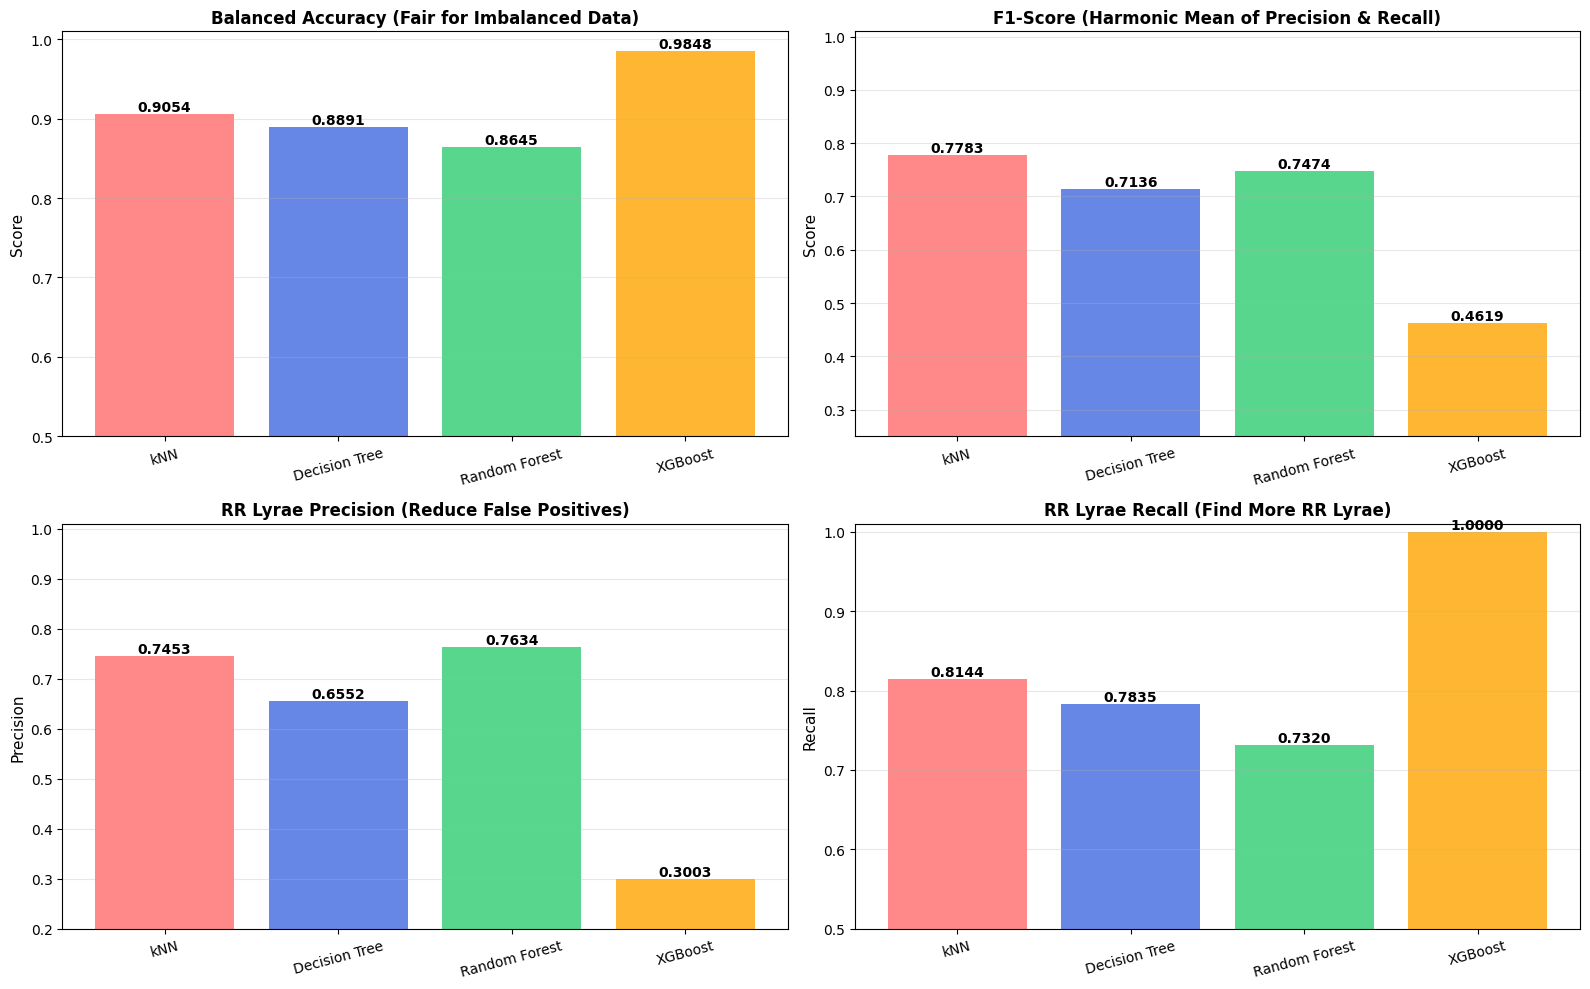


WINNER FOR EACH METRIC
✓ Best Balanced Accuracy:     XGBoost (0.9848)
✓ Best F1-Score:              kNN (0.7783)
✓ Best RR Lyrae Precision:    Random Forest (0.7634)
✓ Best RR Lyrae Recall:       XGBoost (1.0000)


In [42]:
# Calculate metrics for all algorithms
# kNN
knn_balanced_acc = balanced_accuracy_score(y_test, best_knn.predict(X_test))
knn_f1 = f1_score(y_test, best_knn.predict(X_test), pos_label=1.0)
knn_precision = precision_score(y_test, best_knn.predict(X_test), pos_label=1.0)
knn_recall = recall_score(y_test, best_knn.predict(X_test), pos_label=1.0)

# Decision Tree
dt_balanced_acc = balanced_accuracy_score(y_test, best_dt.predict(X_test))
dt_f1 = f1_score(y_test, best_dt.predict(X_test), pos_label=1.0)
dt_precision = precision_score(y_test, best_dt.predict(X_test), pos_label=1.0)
dt_recall = recall_score(y_test, best_dt.predict(X_test), pos_label=1.0)

# Random Forest
rf_balanced_acc = balanced_accuracy_score(y_test, best_rf.predict(X_test))
rf_f1 = f1_score(y_test, best_rf.predict(X_test), pos_label=1.0)
rf_precision = precision_score(y_test, best_rf.predict(X_test), pos_label=1.0)
rf_recall = recall_score(y_test, best_rf.predict(X_test), pos_label=1.0)

# Create comprehensive comparison dataframe
comparison_data_all = {
    'Algorithm': ['kNN', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Balanced Accuracy': [knn_balanced_acc, dt_balanced_acc, rf_balanced_acc, xgb_balanced_acc],
    'F1-Score': [knn_f1, dt_f1, rf_f1, xgb_f1],
    'RR Lyrae Precision': [knn_precision, dt_precision, rf_precision, xgb_precision],
    'RR Lyrae Recall': [knn_recall, dt_recall, rf_recall, xgb_recall]
}

comparison_df_all = pd.DataFrame(comparison_data_all)

# Display comparison table
print("\n" + "="*100)
print("COMPREHENSIVE ALGORITHM COMPARISON - ALL METHODS")
print("="*100)
print(comparison_df_all.to_string(index=False))
print("="*100)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

algorithms = comparison_df_all['Algorithm'].tolist()
colors_algo = ['#FF6B6B', '#4169E1', '#2ECC71', '#FFA500']

# Plot 1: Balanced Accuracy
bars = axes[0, 0].bar(algorithms, comparison_df_all['Balanced Accuracy'], color=colors_algo, alpha=0.8)
axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].set_title('Balanced Accuracy (Fair for Imbalanced Data)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0.5, 1.01])
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=15)

for bar in bars:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: F1-Score
bars = axes[0, 1].bar(algorithms, comparison_df_all['F1-Score'], color=colors_algo, alpha=0.8)
axes[0, 1].set_ylabel('Score', fontsize=11)
axes[0, 1].set_title('F1-Score (Harmonic Mean of Precision & Recall)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0.25, 1.01])
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=15)

for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: RR Lyrae Precision
bars = axes[1, 0].bar(algorithms, comparison_df_all['RR Lyrae Precision'], color=colors_algo, alpha=0.8)
axes[1, 0].set_ylabel('Precision', fontsize=11)
axes[1, 0].set_title('RR Lyrae Precision (Reduce False Positives)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim([0.2, 1.01])
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=15)

for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: RR Lyrae Recall
bars = axes[1, 1].bar(algorithms, comparison_df_all['RR Lyrae Recall'], color=colors_algo, alpha=0.8)
axes[1, 1].set_ylabel('Recall', fontsize=11)
axes[1, 1].set_title('RR Lyrae Recall (Find More RR Lyrae)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0.5, 1.01])
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=15)

for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Find the best algorithm for each metric
print("\n" + "="*100)
print("WINNER FOR EACH METRIC")
print("="*100)
best_ba_idx = comparison_df_all['Balanced Accuracy'].idxmax()
best_f1_idx = comparison_df_all['F1-Score'].idxmax()
best_prec_idx = comparison_df_all['RR Lyrae Precision'].idxmax()
best_recall_idx = comparison_df_all['RR Lyrae Recall'].idxmax()

print(f"✓ Best Balanced Accuracy:     {comparison_df_all.loc[best_ba_idx, 'Algorithm']} "
      f"({comparison_df_all.loc[best_ba_idx, 'Balanced Accuracy']:.4f})")
print(f"✓ Best F1-Score:              {comparison_df_all.loc[best_f1_idx, 'Algorithm']} "
      f"({comparison_df_all.loc[best_f1_idx, 'F1-Score']:.4f})")
print(f"✓ Best RR Lyrae Precision:    {comparison_df_all.loc[best_prec_idx, 'Algorithm']} "
      f"({comparison_df_all.loc[best_prec_idx, 'RR Lyrae Precision']:.4f})")
print(f"✓ Best RR Lyrae Recall:       {comparison_df_all.loc[best_recall_idx, 'Algorithm']} "
      f"({comparison_df_all.loc[best_recall_idx, 'RR Lyrae Recall']:.4f})")
print("="*100)